In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
from pathlib import Path

# Get current notebook path safely
NOTEBOOK_DIR = Path(os.getcwd())

# Set BASE_DIR depending on execution folder
if NOTEBOOK_DIR.name == "notebooks":
    BASE_DIR = NOTEBOOK_DIR.parent
else:
    BASE_DIR = NOTEBOOK_DIR

RAW_DIR = BASE_DIR / "data" / "raw"
metadata_path = RAW_DIR / "amazon_electronics_metadata_sample.parquet"

print("Checking file at:", metadata_path.resolve())
print("File exists?", metadata_path.exists())

Checking file at: C:\Users\Aman\Desktop\TrustGuard\product_scam_ml\data\raw\amazon_electronics_metadata_sample.parquet
File exists? True


In [3]:
metadata = pd.read_parquet(metadata_path)

print("Shape:", metadata.shape)

metadata.head()

Shape: (10000, 16)


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,All Electronics,FS-1051 FATSHARK TELEPORTER V3 HEADSET,3.5,6,[],[Teleporter V3 The “Teleporter V3” kit sets a ...,None,"{'hi_res': [None], 'large': ['https://m.media-...","{'title': [], 'url': [], 'user_id': []}",Fat Shark,"[Electronics, Television & Video, Video Glasses]","{""Date First Available"": ""August 2, 2014"", ""Ma...",B00MCW7G9M,NaN,NaN,NaN
1,All Electronics,Ce-H22B12-S1 4Kx2K Hdmi 4Port,5.0,1,"[UPC: 662774021904, Weight: 0.600 lbs]",[HDMI In - HDMI Out],None,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",SIIG,"[Electronics, Television & Video, Accessories,...","{""Product Dimensions"": ""0.83 x 4.17 x 2.05 inc...",B00YT6XQSE,NaN,NaN,NaN
2,Computers,Digi-Tatoo Decal Skin Compatible With MacBook ...,4.5,246,[WARNING: Please IDENTIFY MODEL NUMBER on the ...,[],19.99,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': ['AL 2Sides Video', 'MacBook Protect...",Digi-Tatoo,"[Electronics, Computers & Accessories, Laptop ...","{""Brand"": ""Digi-Tatoo"", ""Color"": ""Fresh Marble...",B07SM135LS,NaN,NaN,NaN
3,AMAZON FASHION,NotoCity Compatible with Vivoactive 4 band 22m...,4.5,233,[☛NotoCity 22mm band is designed for Vivoactiv...,[],9.99,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",NotoCity,"[Electronics, Wearable Technology, Clips, Arm ...","{""Date First Available"": ""May 29, 2020"", ""Manu...",B089CNGZCW,NaN,NaN,NaN
4,Cell Phones & Accessories,Motorola Droid X Essentials Combo Pack,3.8,64,"[New Droid X Essentials Combo Pack, Exclusive ...",[all Genuine High Quality Motorola Made Access...,14.99,"{'hi_res': [None, None, None, None, None], 'la...","{'title': [], 'url': [], 'user_id': []}",Verizon,"[Electronics, Computers & Accessories, Compute...","{""Product Dimensions"": ""11.6 x 6.9 x 3.1 inche...",B004E2Z88O,NaN,NaN,NaN


In [4]:
print("Available columns:\n")

for i, column in enumerate(metadata.columns, start=1):
    print(f"{i}. {column}")

Available columns:

1. main_category
2. title
3. average_rating
4. rating_number
5. features
6. description
7. price
8. images
9. videos
10. store
11. categories
12. details
13. parent_asin
14. bought_together
15. subtitle
16. author


In [5]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   main_category    9885 non-null   str    
 1   title            10000 non-null  str    
 2   average_rating   10000 non-null  float64
 3   rating_number    10000 non-null  int64  
 4   features         10000 non-null  object 
 5   description      10000 non-null  object 
 6   price            10000 non-null  str    
 7   images           10000 non-null  object 
 8   videos           10000 non-null  object 
 9   store            9938 non-null   str    
 10  categories       10000 non-null  object 
 11  details          10000 non-null  str    
 12  parent_asin      10000 non-null  str    
 13  bought_together  0 non-null      str    
 14  subtitle         3 non-null      str    
 15  author           2 non-null      str    
dtypes: float64(1), int64(1), object(5), str(9)
memory usage: 7.0+ MB


In [6]:
missing = (
    metadata.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_percentage = (
    metadata.isnull()
    .mean()
    .mul(100)
    .round(2)
)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": missing_percentage
})

missing_report

,missing_count,missing_percentage
author,9998,99.98
average_rating,0,0.00
bought_together,10000,100.00
categories,0,0.00
description,0,0.00
details,0,0.00
features,0,0.00
images,0,0.00
main_category,115,1.15
parent_asin,0,0.00


In [7]:
# Select explicitly defined numerical fields only
numeric_columns = ["average_rating", "rating_number"]

# Display statistical summary immediately
metadata[numeric_columns].describe()

,average_rating,rating_number
count,10000.000000,10000.000000
mean,4.076840,503.825900
std,0.737808,3132.790703
min,1.000000,1.000000
25%,3.700000,5.000000
50%,4.200000,22.000000
75%,4.600000,114.000000
max,5.000000,143891.000000


In [8]:
metadata["average_rating"].value_counts().sort_index()

average_rating
1.0     150
1.2       1
1.3       1
1.4       2
1.5      15
1.6       2
1.7       7
1.8       5
1.9       8
2.0      66
2.1      10
2.2      15
2.3      24
2.4      19
2.5      53
2.6      42
2.7      36
2.8      57
2.9      76
3.0     275
3.1     131
3.2     144
3.3     229
3.4     238
3.5     292
3.6     288
3.7     324
3.8     391
3.9     414
4.0     661
4.1     568
4.2     616
4.3     654
4.4     707
4.5     854
4.6     732
4.7     562
4.8     268
4.9      52
5.0    1011
Name: count, dtype: int64

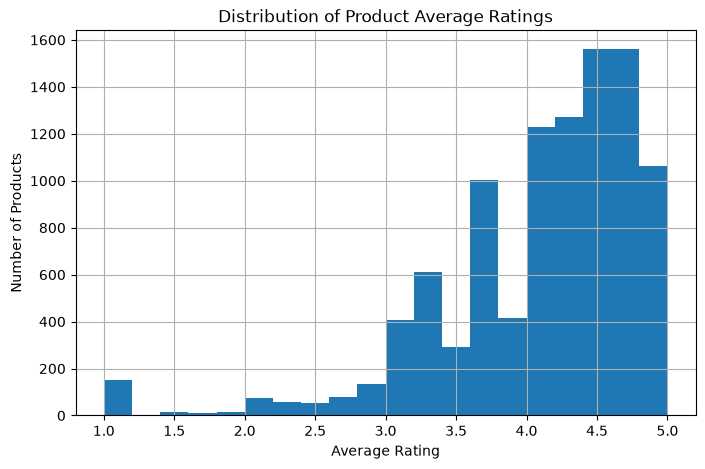

In [9]:
plt.figure(figsize=(8, 5))

metadata["average_rating"].hist(bins=20)

plt.xlabel("Average Rating")
plt.ylabel("Number of Products")
plt.title("Distribution of Product Average Ratings")

plt.show()

In [10]:
metadata["rating_number"].describe()

count     10000.000000
mean        503.825900
std        3132.790703
min           1.000000
25%           5.000000
50%          22.000000
75%         114.000000
max      143891.000000
Name: rating_number, dtype: float64

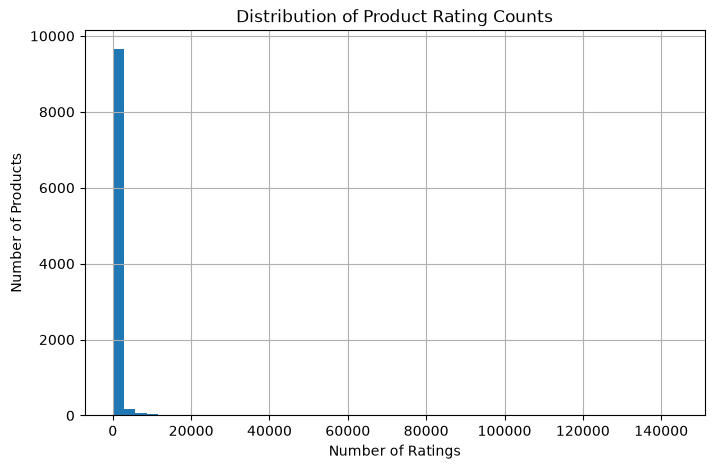

In [11]:
plt.figure(figsize=(8, 5))

metadata["rating_number"].hist(bins=50)

plt.xlabel("Number of Ratings")
plt.ylabel("Number of Products")
plt.title("Distribution of Product Rating Counts")

plt.show()

In [12]:
metadata[
    ["parent_asin", "title", "average_rating", "rating_number"]
].head(20)

,parent_asin,title,average_rating,rating_number
0,B00MCW7G9M,FS-1051 FATSHARK TELEPORTER V3 HEADSET,3.5,6
1,B00YT6XQSE,Ce-H22B12-S1 4Kx2K Hdmi 4Port,5.0,1
2,B07SM135LS,Digi-Tatoo Decal Skin Compatible With MacBook ...,4.5,246
3,B089CNGZCW,NotoCity Compatible with Vivoactive 4 band 22m...,4.5,233
4,B004E2Z88O,Motorola Droid X Essentials Combo Pack,3.8,64
5,B00TX536EK,Raymarine Wi-Fish DownVision Blackbox Sonar wi...,3.5,25
6,B07BJ7ZZL7,"QGHXO Band for Garmin Vivofit 4, Soft Silicone...",4.4,707
7,B005G99O2U,Protech iPhone 4 microscope 60X Lens with illu...,3.8,6
8,B01MCZP7RF,MOSISO Plastic Hard Shell Case & Keyboard Cove...,5.0,2
9,B00R6R82HS,"Fishfinder, Depth Finder Poly Sun Cover for 3""...",4.4,86


In [13]:
metadata["price"].head(20)

0       None
1       None
2      19.99
3       9.99
4      14.99
5       None
6      14.89
7       None
8       None
9      10.99
10      None
11      None
12      None
13      None
14      8.98
15      None
16    909.99
17     98.49
18      None
19      3.99
Name: price, dtype: str

In [14]:
metadata["price"].dtype

<StringDtype(na_value=nan)>

In [15]:
metadata["categories"].head()

0     [Electronics, Television & Video, Video Glasses]
1    [Electronics, Television & Video, Accessories,...
2    [Electronics, Computers & Accessories, Laptop ...
3    [Electronics, Wearable Technology, Clips, Arm ...
4    [Electronics, Computers & Accessories, Compute...
Name: categories, dtype: object

In [16]:
metadata["main_category"].value_counts().head(20)

main_category
Computers                       2941
All Electronics                 2445
Camera & Photo                  1276
Cell Phones & Accessories        985
Home Audio & Theater             633
Industrial & Scientific          331
Tools & Home Improvement         172
Car Electronics                  170
AMAZON FASHION                   164
Amazon Home                      148
Office Products                  135
Sports & Outdoors                106
Automotive                        64
Amazon Devices                    55
GPS & Navigation                  53
Musical Instruments               49
Portable Audio & Accessories      48
Toys & Games                      24
Health & Personal Care            17
All Beauty                        16
Name: count, dtype: int64

In [17]:
metadata["features"].head()

0                                                   []
1               [UPC: 662774021904, Weight: 0.600 lbs]
2    [WARNING: Please IDENTIFY MODEL NUMBER on the ...
3    [☛NotoCity 22mm band is designed for Vivoactiv...
4    [New Droid X Essentials Combo Pack, Exclusive ...
Name: features, dtype: object

In [18]:
metadata.iloc[0]["features"]

array([], dtype=object)

In [19]:
metadata[
    ["title", "description"]
].head(10)

,title,description
0,FS-1051 FATSHARK TELEPORTER V3 HEADSET,[Teleporter V3 The “Teleporter V3” kit sets a ...
1,Ce-H22B12-S1 4Kx2K Hdmi 4Port,[HDMI In - HDMI Out]
2,Digi-Tatoo Decal Skin Compatible With MacBook ...,[]
3,NotoCity Compatible with Vivoactive 4 band 22m...,[]
4,Motorola Droid X Essentials Combo Pack,[all Genuine High Quality Motorola Made Access...
5,Raymarine Wi-Fish DownVision Blackbox Sonar wi...,[Transform your smartphone into a powerful CHI...
6,"QGHXO Band for Garmin Vivofit 4, Soft Silicone...","[Compatibility, Custom designed for your preci..."
7,Protech iPhone 4 microscope 60X Lens with illu...,[This accessory will convert your iPhone 4 int...
8,MOSISO Plastic Hard Shell Case & Keyboard Cove...,[]
9,"Fishfinder, Depth Finder Poly Sun Cover for 3""...",[Affordable and convenient way to cover your s...


In [20]:
metadata.iloc[0]["description"]

array(['Teleporter V3 The “Teleporter V3” kit sets a new level of value in the FPV world with Fat Shark renowned performance and quality. The fun of FPV is experienced firsthand through the large screen FPV headset with integrated NexwaveRF receiver technology while simultaneously recording onboard HD footage with the included “PilotHD” camera. The “Teleporter V3” kit comes complete with everything you need to step into the cockpit of your FPV vehicle. We’ve included our powerful 250mW 5.8Ghz transmitter, 25 degree FOV headset (largest QVGA display available), the brand new “PilotHD” camera with live AV out and all the cables, antennas and connectors needed.'],
      dtype=object)

In [21]:
metadata.head(3).to_dict()

{'main_category': {0: 'All Electronics', 1: 'All Electronics', 2: 'Computers'},
 'title': {0: 'FS-1051 FATSHARK TELEPORTER V3 HEADSET',
  1: 'Ce-H22B12-S1 4Kx2K Hdmi 4Port',
  2: 'Digi-Tatoo Decal Skin Compatible With MacBook Pro 13 inch (Model A2338/ A2289/ A2251) - Protective and Decorative Full Body Laptop Skin Decal Sticker, Anti-Scratch Vinly Skin Sticker Wrap [Fresh Marble]'},
 'average_rating': {0: 3.5, 1: 5.0, 2: 4.5},
 'rating_number': {0: 6, 1: 1, 2: 246},
 'features': {0: array([], dtype=object),
  1: array(['UPC: 662774021904', 'Weight: 0.600 lbs'], dtype=object),
  2: array(['WARNING: Please IDENTIFY MODEL NUMBER on the bottom of your Macbook. Only fits for model A2338/ A2289/ A2251 (Macbook Pro 13" w/ Touch Bar, 2022/2020 release).',
         'Extra Care Yet Not Bulky. Our skin is capable of protecting the surface of your Macbook from daily scratches, dust, oil, water and fingerprint. Your Macbook remains fresh some years later.',
         'Elegant Style. Our stylish desi

In [22]:
missing_report

,missing_count,missing_percentage
author,9998,99.98
average_rating,0,0.00
bought_together,10000,100.00
categories,0,0.00
description,0,0.00
details,0,0.00
features,0,0.00
images,0,0.00
main_category,115,1.15
parent_asin,0,0.00


In [23]:
metadata["average_rating"].describe()

count    10000.000000
mean         4.076840
std          0.737808
min          1.000000
25%          3.700000
50%          4.200000
75%          4.600000
max          5.000000
Name: average_rating, dtype: float64

In [24]:
metadata["rating_number"].describe()

count     10000.000000
mean        503.825900
std        3132.790703
min           1.000000
25%           5.000000
50%          22.000000
75%         114.000000
max      143891.000000
Name: rating_number, dtype: float64

In [25]:
metadata["price"].head(20)

0       None
1       None
2      19.99
3       9.99
4      14.99
5       None
6      14.89
7       None
8       None
9      10.99
10      None
11      None
12      None
13      None
14      8.98
15      None
16    909.99
17     98.49
18      None
19      3.99
Name: price, dtype: str

In [26]:
metadata["main_category"].value_counts().head(20)

main_category
Computers                       2941
All Electronics                 2445
Camera & Photo                  1276
Cell Phones & Accessories        985
Home Audio & Theater             633
Industrial & Scientific          331
Tools & Home Improvement         172
Car Electronics                  170
AMAZON FASHION                   164
Amazon Home                      148
Office Products                  135
Sports & Outdoors                106
Automotive                        64
Amazon Devices                    55
GPS & Navigation                  53
Musical Instruments               49
Portable Audio & Accessories      48
Toys & Games                      24
Health & Personal Care            17
All Beauty                        16
Name: count, dtype: int64

In [27]:
metadata.iloc[0]["features"]

array([], dtype=object)

In [28]:
metadata.iloc[0]["description"]

array(['Teleporter V3 The “Teleporter V3” kit sets a new level of value in the FPV world with Fat Shark renowned performance and quality. The fun of FPV is experienced firsthand through the large screen FPV headset with integrated NexwaveRF receiver technology while simultaneously recording onboard HD footage with the included “PilotHD” camera. The “Teleporter V3” kit comes complete with everything you need to step into the cockpit of your FPV vehicle. We’ve included our powerful 250mW 5.8Ghz transmitter, 25 degree FOV headset (largest QVGA display available), the brand new “PilotHD” camera with live AV out and all the cables, antennas and connectors needed.'],
      dtype=object)

In [30]:
%whos

Variable             Type           Data/Info
---------------------------------------------
BASE_DIR             WindowsPath    C:\Users\Aman\Desktop\TrustGuard\product_scam_ml
NOTEBOOK_DIR         WindowsPath    C:\Users\Aman\Desktop\Tru<...>product_scam_ml\notebooks
Path                 type           <class 'pathlib.Path'>
RAW_DIR              WindowsPath    C:\Users\Aman\Desktop\Tru<...>\product_scam_ml\data\raw
column               str            author
i                    int            16
metadata             DataFrame      Shape: (10000, 16)
metadata_path        WindowsPath    C:\Users\Aman\Desktop\Tru<...>s_metadata_sample.parquet
missing              Series         Shape: (16,)
missing_percentage   Series         Shape: (16,)
missing_report       DataFrame      Shape: (16, 2)
np                   module         <module 'numpy' from 'C:\<...>ges\\numpy\\__init__.py'>
numeric_columns      list           n=2
os                   module         <module 'os' (frozen)>
pd         

In [31]:
df = metadata.copy()

print("Original shape:", df.shape)

Original shape: (10000, 16)


In [32]:
drop_cols = [
    "bought_together",
    "subtitle",
    "author"
]

df = df.drop(columns=drop_cols)

print("Shape after dropping unusable columns:", df.shape)
print(df.columns.tolist())

Shape after dropping unusable columns: (10000, 13)
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin']


In [33]:
df["price_numeric"] = (
    df["price"]
    .replace("None", np.nan)
    .astype(float)
)

print(df["price_numeric"].describe())
print("\nMissing prices:", df["price_numeric"].isna().sum())

count     4282.000000
mean        88.707022
std        335.998426
min          0.930000
25%         11.990000
50%         20.390000
75%         49.990000
max      12998.000000
Name: price_numeric, dtype: float64

Missing prices: 5718


In [34]:
for col in ["features", "description", "images", "videos", "categories"]:
    print(f"\n--- {col} ---")
    print("Type:", type(df[col].iloc[0]))
    print("Value:", df[col].iloc[0])


--- features ---
Type: <class 'numpy.ndarray'>
Value: []

--- description ---
Type: <class 'numpy.ndarray'>
Value: ['Teleporter V3 The “Teleporter V3” kit sets a new level of value in the FPV world with Fat Shark renowned performance and quality. The fun of FPV is experienced firsthand through the large screen FPV headset with integrated NexwaveRF receiver technology while simultaneously recording onboard HD footage with the included “PilotHD” camera. The “Teleporter V3” kit comes complete with everything you need to step into the cockpit of your FPV vehicle. We’ve included our powerful 250mW 5.8Ghz transmitter, 25 degree FOV headset (largest QVGA display available), the brand new “PilotHD” camera with live AV out and all the cables, antennas and connectors needed.']

--- images ---
Type: <class 'dict'>
Value: {'hi_res': array([None], dtype=object), 'large': array(['https://m.media-amazon.com/images/I/41qrX56lsYL._AC_.jpg'],
      dtype=object), 'thumb': array(['https://m.media-amazon

In [35]:
def count_array_items(value):
    """Count meaningful items inside a numpy array/list."""
    if value is None:
        return 0

    if isinstance(value, np.ndarray):
        return sum(
            1 for item in value
            if item is not None and str(item).strip() != ""
        )

    if isinstance(value, (list, tuple)):
        return sum(
            1 for item in value
            if item is not None and str(item).strip() != ""
        )

    return 0


def combine_array_text(value):
    """Combine text stored inside numpy arrays/lists into one string."""
    if value is None:
        return ""

    if isinstance(value, np.ndarray):
        items = value.tolist()
    elif isinstance(value, (list, tuple)):
        items = list(value)
    else:
        return str(value)

    return " ".join(
        str(item).strip()
        for item in items
        if item is not None and str(item).strip() != ""
    )


def count_dict_array_items(value, key):
    """Count items stored under a key inside a dictionary."""
    if not isinstance(value, dict):
        return 0

    items = value.get(key, [])

    return count_array_items(items)

In [36]:
print("Features count:",
      count_array_items(df["features"].iloc[0]))

print("Description text:")
print(combine_array_text(df["description"].iloc[0]))

print("\nImage count:",
      count_dict_array_items(df["images"].iloc[0], "large"))

print("Video count:",
      count_dict_array_items(df["videos"].iloc[0], "url"))

print("Category count:",
      count_array_items(df["categories"].iloc[0]))

Features count: 0
Description text:
Teleporter V3 The “Teleporter V3” kit sets a new level of value in the FPV world with Fat Shark renowned performance and quality. The fun of FPV is experienced firsthand through the large screen FPV headset with integrated NexwaveRF receiver technology while simultaneously recording onboard HD footage with the included “PilotHD” camera. The “Teleporter V3” kit comes complete with everything you need to step into the cockpit of your FPV vehicle. We’ve included our powerful 250mW 5.8Ghz transmitter, 25 degree FOV headset (largest QVGA display available), the brand new “PilotHD” camera with live AV out and all the cables, antennas and connectors needed.

Image count: 1
Video count: 0
Category count: 3


In [37]:
df["title_length"] = df["title"].fillna("").str.len()

df["title_word_count"] = (
    df["title"]
    .fillna("")
    .str.split()
    .str.len()
)

df["uppercase_ratio"] = (
    df["title"]
    .fillna("")
    .apply(
        lambda x: sum(c.isupper() for c in x) / len(x)
        if len(x) > 0 else 0
    )
)

df["special_character_ratio"] = (
    df["title"]
    .fillna("")
    .apply(
        lambda x: sum(
            not c.isalnum() and not c.isspace()
            for c in x
        ) / len(x)
        if len(x) > 0 else 0
    )
)

In [38]:
df["description_text"] = df["description"].apply(combine_array_text)

df["description_length"] = df["description_text"].str.len()

df["description_word_count"] = (
    df["description_text"]
    .str.split()
    .str.len()
)

In [39]:
df["feature_count"] = (
    df["features"]
    .apply(count_array_items)
)

df["feature_text"] = (
    df["features"]
    .apply(combine_array_text)
)

df["feature_text_length"] = (
    df["feature_text"]
    .str.len()
)

In [40]:
df["image_count"] = (
    df["images"]
    .apply(lambda x: count_dict_array_items(x, "large"))
)

df["has_images"] = (
    df["image_count"] > 0
).astype(int)

In [41]:
df["video_count"] = (
    df["videos"]
    .apply(lambda x: count_dict_array_items(x, "url"))
)

df["has_videos"] = (
    df["video_count"] > 0
).astype(int)

In [42]:
df["category_count"] = (
    df["categories"]
    .apply(count_array_items)
)

In [43]:
df["seller_missing"] = (
    df["store"].isna()
).astype(int)

df["seller_name_length"] = (
    df["store"]
    .fillna("")
    .astype(str)
    .str.len()
)

In [44]:
new_features = [
    "title_length",
    "title_word_count",
    "uppercase_ratio",
    "special_character_ratio",
    "description_length",
    "description_word_count",
    "feature_count",
    "feature_text_length",
    "image_count",
    "has_images",
    "video_count",
    "has_videos",
    "category_count",
    "seller_missing",
    "seller_name_length",
    "price_numeric"
]

df[new_features].describe()

,title_length,title_word_count,uppercase_ratio,special_character_ratio,description_length,description_word_count,feature_count,feature_text_length,image_count,has_images,video_count,has_videos,category_count,seller_missing,seller_name_length,price_numeric
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.0,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,4282.000000
mean,127.208400,19.770800,0.189629,0.040271,480.851900,76.047200,3.735900,544.194000,5.27590,1.0,2.655200,0.422200,4.107100,0.0062,7.821900,88.707022
std,55.523979,8.939041,0.073833,0.027267,920.807882,144.989004,2.290082,544.620353,2.71122,0.0,3.899645,0.493935,1.462547,0.0785,4.068247,335.998426
min,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,1.0,0.000000,0.000000,0.000000,0.0000,0.000000,0.930000
25%,79.000000,12.000000,0.142132,0.020408,0.000000,0.000000,2.000000,66.000000,3.00000,1.0,0.000000,0.000000,4.000000,0.0000,6.000000,11.990000
50%,130.000000,20.000000,0.172414,0.037290,110.500000,17.000000,5.000000,380.500000,6.00000,1.0,0.000000,0.000000,4.000000,0.0000,7.000000,20.390000
75%,179.000000,27.000000,0.217391,0.056604,683.000000,108.000000,5.000000,885.250000,7.00000,1.0,5.000000,1.000000,5.000000,0.0000,9.000000,49.990000
max,534.000000,91.000000,1.000000,0.225806,21055.000000,3251.000000,19.000000,4216.000000,26.00000,1.0,10.000000,1.000000,7.000000,1.0000,64.000000,12998.000000


In [45]:
print(df[new_features].isna().sum())

title_length                  0
title_word_count              0
uppercase_ratio               0
special_character_ratio       0
description_length            0
description_word_count        0
feature_count                 0
feature_text_length           0
image_count                   0
has_images                    0
video_count                   0
has_videos                    0
category_count                0
seller_missing                0
seller_name_length            0
price_numeric              5718
dtype: int64


In [46]:
# Check feature variance and unique values

feature_columns = [
    "title_length",
    "title_word_count",
    "uppercase_ratio",
    "special_character_ratio",
    "description_length",
    "description_word_count",
    "feature_count",
    "feature_text_length",
    "image_count",
    "has_images",
    "video_count",
    "has_videos",
    "category_count",
    "seller_missing",
    "seller_name_length",
    "price_numeric",
    "average_rating",
    "rating_number"
]

variance_report = pd.DataFrame({
    "feature": feature_columns,
    "unique_values": [df[col].nunique(dropna=False) for col in feature_columns],
    "missing": [df[col].isna().sum() for col in feature_columns],
    "variance": [
        df[col].var() if pd.api.types.is_numeric_dtype(df[col]) else np.nan
        for col in feature_columns
    ]
})

variance_report

,feature,unique_values,missing,variance
0,title_length,266,0,3.082912e+03
1,title_word_count,62,0,7.990646e+01
2,uppercase_ratio,2515,0,5.451324e-03
3,special_character_ratio,1338,0,7.434656e-04
4,description_length,1957,0,8.478872e+05
5,description_word_count,527,0,2.102181e+04
6,feature_count,18,0,5.244476e+00
7,feature_text_length,1898,0,2.966113e+05
8,image_count,22,0,7.350714e+00
9,has_images,1,0,0.000000e+00


In [47]:
df["price_missing"] = df["price_numeric"].isna().astype(int)

df["log_rating_number"] = np.log1p(df["rating_number"])

print("Added:")
print("- price_missing")
print("- log_rating_number")

print("\nNew shape:", df.shape)

Added:
- price_missing
- log_rating_number

New shape: (10000, 33)


In [48]:
df.drop(columns=["has_images"], inplace=True)

In [49]:
# Current numerical features

feature_columns = [
    "title_length",
    "title_word_count",
    "uppercase_ratio",
    "special_character_ratio",
    "description_length",
    "description_word_count",
    "feature_count",
    "feature_text_length",
    "image_count",
    "video_count",
    "has_videos",
    "category_count",
    "seller_missing",
    "seller_name_length",
    "price_numeric",
    "price_missing",
    "average_rating",
    "rating_number",
    "log_rating_number"
]

correlation_matrix = df[feature_columns].corr()

correlation_matrix.round(2)

,title_length,title_word_count,uppercase_ratio,special_character_ratio,description_length,description_word_count,feature_count,feature_text_length,image_count,video_count,has_videos,category_count,seller_missing,seller_name_length,price_numeric,price_missing,average_rating,rating_number,log_rating_number
title_length,1.00,0.95,-0.19,0.07,-0.09,-0.09,0.09,0.43,0.45,0.27,0.27,0.03,-0.02,-0.09,-0.04,-0.15,0.09,0.06,0.24
title_word_count,0.95,1.00,-0.15,0.05,-0.09,-0.09,0.07,0.40,0.44,0.26,0.25,0.04,-0.02,-0.09,-0.02,-0.13,0.09,0.06,0.23
uppercase_ratio,-0.19,-0.15,1.00,0.10,0.04,0.03,-0.03,-0.12,-0.13,-0.08,-0.08,0.04,-0.01,-0.02,0.09,0.00,-0.02,-0.04,-0.12
special_character_ratio,0.07,0.05,0.10,1.00,0.06,0.06,0.05,0.00,-0.00,0.05,0.03,0.05,-0.03,-0.02,0.10,-0.01,0.02,0.03,0.04
description_length,-0.09,-0.09,0.04,0.06,1.00,1.00,0.24,0.06,-0.04,-0.04,-0.01,0.07,-0.04,0.01,0.06,0.01,-0.05,-0.03,0.00
description_word_count,-0.09,-0.09,0.03,0.06,1.00,1.00,0.24,0.06,-0.04,-0.04,-0.01,0.07,-0.04,0.01,0.06,0.01,-0.05,-0.03,0.01
feature_count,0.09,0.07,-0.03,0.05,0.24,0.24,1.00,0.61,0.14,0.32,0.34,0.27,-0.13,0.01,0.03,-0.34,0.09,0.10,0.32
feature_text_length,0.43,0.40,-0.12,0.00,0.06,0.06,0.61,1.00,0.38,0.49,0.46,0.19,-0.08,-0.05,-0.00,-0.34,0.13,0.11,0.39
image_count,0.45,0.44,-0.13,-0.00,-0.04,-0.04,0.14,0.38,1.00,0.35,0.32,0.03,-0.04,-0.10,0.06,-0.11,0.08,0.09,0.33
video_count,0.27,0.26,-0.08,0.05,-0.04,-0.04,0.32,0.49,0.35,1.00,0.80,0.12,-0.05,-0.06,0.10,-0.46,0.17,0.21,0.53


In [50]:
# Find highly correlated feature pairs

high_corr_pairs = []

for i in range(len(feature_columns)):
    for j in range(i + 1, len(feature_columns)):
        
        corr = correlation_matrix.iloc[i, j]
        
        if abs(corr) >= 0.80:
            high_corr_pairs.append({
                "feature_1": feature_columns[i],
                "feature_2": feature_columns[j],
                "correlation": corr
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

high_corr_df.sort_values(
    "correlation",
    key=lambda x: abs(x),
    ascending=False
)

,feature_1,feature_2,correlation
1,description_length,description_word_count,0.997121
0,title_length,title_word_count,0.951500


In [51]:
print("Price availability")
print(df["price_missing"].value_counts())

print("\nPrice quantiles:")
print(df["price_numeric"].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

Price availability
price_missing
1    5718
0    4282
Name: count, dtype: int64

Price quantiles:
count     4282.000000
mean        88.707022
std        335.998426
min          0.930000
1%           4.950000
5%           6.950000
10%          7.990000
25%         11.990000
50%         20.390000
75%         49.990000
90%        159.000000
95%        331.736000
99%       1303.457500
max      12998.000000
Name: price_numeric, dtype: float64


In [52]:
print(
    df[["average_rating", "rating_number", "log_rating_number"]]
    .describe()
)

       average_rating  rating_number  log_rating_number
count    10000.000000   10000.000000       10000.000000
mean         4.076840     503.825900           3.480023
std          0.737808    3132.790703           2.068254
min          1.000000       1.000000           0.693147
25%          3.700000       5.000000           1.791759
50%          4.200000      22.000000           3.135494
75%          4.600000     114.000000           4.744932
max          5.000000  143891.000000          11.876818


In [53]:
print("Very high rating + low review count:")

print(
    df[
        (df["average_rating"] >= 4.8) &
        (df["rating_number"] <= 10)
    ][
        ["title", "average_rating", "rating_number", "price_numeric"]
    ].head(20)
)

Very high rating + low review count:
                                                 title  average_rating  \
1                        Ce-H22B12-S1 4Kx2K Hdmi 4Port             5.0   
8    MOSISO Plastic Hard Shell Case & Keyboard Cove...             5.0   
16   ANNKE 4K 16CH Security DVR Recorder with Human...             5.0   
17   BIPRA U3 2.5 inch USB 3.0 NTFS Portable Extern...             5.0   
26               HTC Vivid Black/Blue Perforated Cover             5.0   
36   Simplistex (TM) - Adjustable Folding Laptop Co...             5.0   
42   Centon Electronics Flash Memory Card (S1-SDHU1...             4.8   
45   Hosa Cable SKT450 Speakon to Banana Plug Speak...             5.0   
57   Superheadz Golden Half Black Mountain 35mm Fil...             5.0   
72   Bluetooth Audio Speaker Power Amplifier - Port...             5.0   
89   Desk Clamp Mount Suspension Arm Stand Holder f...             5.0   
96   SSV Works Polaris Ranger XP9 900 2012-up and F...             5.0   
9

In [54]:
df["category_price_median"] = (
    df.groupby("main_category")["price_numeric"]
      .transform("median")
)

In [55]:
df["price_ratio_to_category"] = (
    df["price_numeric"] / df["category_price_median"]
)

In [56]:
print(
    df["price_ratio_to_category"]
    .describe(percentiles=[0.01, 0.05, 0.10, 0.90, 0.95, 0.99])
)

count    4230.000000
mean        3.650664
std        12.181786
min         0.016121
1%          0.184143
5%          0.285469
10%         0.379544
90%         6.763505
95%        14.005202
99%        49.002001
max       371.424489
Name: price_ratio_to_category, dtype: float64


In [57]:
df["log_price_ratio"] = np.log1p(df["price_ratio_to_category"])

In [58]:
print(df["log_price_ratio"].describe())

count    4230.000000
mean        0.967276
std         0.793176
min         0.015993
25%         0.451855
50%         0.693147
75%         1.182412
max         5.920034
Name: log_price_ratio, dtype: float64


In [59]:
print(
    df[[
        "title",
        "price_numeric",
        "price_ratio_to_category",
        "log_price_ratio"
    ]]
    .sort_values("price_ratio_to_category", ascending=False)
    .head(20)
)

                                                  title  price_numeric  \
1770  FE 600mm F4 GM Super Telephoto Lens (SEL600F40GM)       12998.00   
5900  Epson EpiqVision Ultra LS500 Laser Ultra Short...        3999.98   
9719  Nikon D6 DSLR Camera (Body Only) (1624) + Niko...        6939.95   
9298  Alienware Aurora R11 Gaming Desktop 10th Gen I...        3998.00   
5433  Sony XBR-65A9G 65-inch TV: MASTER Series BRAVI...        2999.00   
6637  Epson Home Cinema 5050UB 4K PRO-UHD 3-Chip Pro...        2879.00   
7972  Microsoft Surface Book 3 (SNK-00001) | 15in (3...        3499.99   
8035  8 Input 8 Output Video Wall 4K 60hz Controller...        2499.99   
3180  Logitech Rally Plus Video Video Conference Equ...        2416.33   
8925  Dell 2022 Vostro 14 5000 5410 Business Laptop ...        2996.00   
8484  LG OLED GX Series 65” Alexa built-in Smart TV ...        1999.99   
600   KanDao 8K 360° Full View Camera, Live Event St...        1999.00   
4827  Corsair ONE a200 Compact Gaming 

In [60]:
df["rating_review_risk"] = (
    df["average_rating"] * (1 / (df["log_rating_number"] + 1))
)

In [61]:
print(df["rating_review_risk"].describe())

count    10000.000000
mean         1.115388
std          0.606557
min          0.324734
25%          0.702196
50%          0.912677
75%          1.302963
max          2.953081
Name: rating_review_risk, dtype: float64


In [62]:
print(
    df[
        [
            "title",
            "average_rating",
            "rating_number",
            "log_rating_number",
            "rating_review_risk"
        ]
    ]
    .sort_values("rating_review_risk", ascending=False)
    .head(20)
)

                                                  title  average_rating  \
2072  Directed Electronics 65310 3ft. Graphite Serie...             5.0   
2062  New 15.6" WXGA Glossy LED Screen For Toshiba S...             5.0   
9986  Best Kits BKCDK644 In-Dash Installation Kit Ch...             5.0   
9934  Intel BOXDZ77GA70K -LGA 1155 Intel Z77 SATA 6G...             5.0   
9942            Atmel-ICE Debugger and Programmer Basic             5.0   
9963  Electrified PD525 PD-525 Replacement Lamp with...             5.0   
5594  CSE-M28SAB-OEM - SUPERMICRO CSE-M28SAB-OEM Sup...             5.0   
9900  Dual Cassette Deck Component with Microphone I...             5.0   
9884  Intel S3000PT Single Board BPTVBB D60098-204 S...             5.0   
9883                             Samlex Dc Power Source             5.0   
2157  Usdepant Bike Kettle - type Storage Bag, Snake...             5.0   
2143  IVSO All-New Fire HD 10 Tablet Case, Auto Wake...             5.0   
2119  hudiemm0B HDD PCI B

In [63]:
df["high_rating"] = (df["average_rating"] >= 4.8).astype(int)

In [64]:
df["low_review_count"] = (df["rating_number"] <= 10).astype(int)

In [65]:
df["high_rating_low_reviews"] = (
    (df["average_rating"] >= 4.8) &
    (df["rating_number"] <= 10)
).astype(int)

In [66]:
print(df["high_rating_low_reviews"].value_counts())

high_rating_low_reviews
0    8930
1    1070
Name: count, dtype: int64


In [67]:
df["price_anomaly"] = (
    df["price_ratio_to_category"] >= 5
).astype(int)

In [68]:
new_risk_features = [
    "price_ratio_to_category",
    "log_price_ratio",
    "price_anomaly",
    "rating_review_risk",
    "high_rating",
    "low_review_count",
    "high_rating_low_reviews"
]

print(df[new_risk_features].describe())

       price_ratio_to_category  log_price_ratio  price_anomaly  \
count              4230.000000      4230.000000   10000.000000   
mean                  3.650664         0.967276       0.055500   
std                  12.181786         0.793176       0.228965   
min                   0.016121         0.015993       0.000000   
25%                   0.571224         0.451855       0.000000   
50%                   1.000000         0.693147       0.000000   
75%                   2.262234         1.182412       0.000000   
max                 371.424489         5.920034       1.000000   

       rating_review_risk  high_rating  low_review_count  \
count        10000.000000   10000.0000      10000.000000   
mean             1.115388       0.1331          0.367100   
std              0.606557       0.3397          0.482038   
min              0.324734       0.0000          0.000000   
25%              0.702196       0.0000          0.000000   
50%              0.912677       0.0000       

In [69]:
print(df[new_risk_features].isna().sum())

price_ratio_to_category    5770
log_price_ratio            5770
price_anomaly                 0
rating_review_risk            0
high_rating                   0
low_review_count              0
high_rating_low_reviews       0
dtype: int64


In [70]:
df["rating_extremeness"] = abs(df["average_rating"] - 3.0)

print(df["rating_extremeness"].describe())

count    10000.00000
mean         1.18568
std          0.54597
min          0.00000
25%          0.80000
50%          1.30000
75%          1.60000
max          2.00000
Name: rating_extremeness, dtype: float64


In [72]:
feature_columns = [
    # Product content
    "title_length",
    "title_word_count",
    "uppercase_ratio",
    "special_character_ratio",
    "description_length",
    "description_word_count",
    "feature_count",
    "feature_text_length",
    "category_count",

    # Marketplace presence
    "image_count",
    "video_count",
    "has_videos",

    # Seller
    "seller_missing",
    "seller_name_length",

    # Price
    "price_numeric",
    "price_missing",
    "price_ratio_to_category",
    "log_price_ratio",
    "price_anomaly",

    # Reputation
    "average_rating",
    "rating_number",
    "log_rating_number",
    "rating_extremeness",
    "high_rating",
    "low_review_count",
    "high_rating_low_reviews",
]

print("Number of features:", len(feature_columns))

print("\nMissing values:")
print(df[feature_columns].isna().sum())

print("\nFeature dataframe shape:")
print(df[feature_columns].shape)

Number of features: 26

Missing values:
title_length                  0
title_word_count              0
uppercase_ratio               0
special_character_ratio       0
description_length            0
description_word_count        0
feature_count                 0
feature_text_length           0
category_count                0
image_count                   0
video_count                   0
has_videos                    0
seller_missing                0
seller_name_length            0
price_numeric              5718
price_missing                 0
price_ratio_to_category    5770
log_price_ratio            5770
price_anomaly                 0
average_rating                0
rating_number                 0
log_rating_number             0
rating_extremeness            0
high_rating                   0
low_review_count              0
high_rating_low_reviews       0
dtype: int64

Feature dataframe shape:
(10000, 26)


In [73]:
print("===== FINAL FEATURE SUMMARY =====")

for col in feature_columns:
    print(f"\n{col}")
    print("  dtype :", df[col].dtype)
    print("  missing:", df[col].isna().sum())
    print("  unique :", df[col].nunique())

print("\n===== FEATURE RANGES =====")

summary = df[feature_columns].describe().T[
    ["min", "25%", "50%", "75%", "max"]
]

display(summary)

===== FINAL FEATURE SUMMARY =====

title_length
  dtype : int64
  missing: 0
  unique : 266

title_word_count
  dtype : int64
  missing: 0
  unique : 62

uppercase_ratio
  dtype : float64
  missing: 0
  unique : 2515

special_character_ratio
  dtype : float64
  missing: 0
  unique : 1338

description_length
  dtype : int64
  missing: 0
  unique : 1957

description_word_count
  dtype : int64
  missing: 0
  unique : 527

feature_count
  dtype : int64
  missing: 0
  unique : 18

feature_text_length
  dtype : int64
  missing: 0
  unique : 1898

category_count
  dtype : int64
  missing: 0
  unique : 7

image_count
  dtype : int64
  missing: 0
  unique : 22

video_count
  dtype : int64
  missing: 0
  unique : 11

has_videos
  dtype : int64
  missing: 0
  unique : 2

seller_missing
  dtype : int64
  missing: 0
  unique : 2

seller_name_length
  dtype : int64
  missing: 0
  unique : 41

price_numeric
  dtype : float64
  missing: 5718
  unique : 1454

price_missing
  dtype : int64
  missing: 0


,min,25%,50%,75%,max
title_length,3.000000,79.000000,130.000000,179.000000,534.000000
title_word_count,1.000000,12.000000,20.000000,27.000000,91.000000
uppercase_ratio,0.000000,0.142132,0.172414,0.217391,1.000000
special_character_ratio,0.000000,0.020408,0.037290,0.056604,0.225806
description_length,0.000000,0.000000,110.500000,683.000000,21055.000000
description_word_count,0.000000,0.000000,17.000000,108.000000,3251.000000
feature_count,0.000000,2.000000,5.000000,5.000000,19.000000
feature_text_length,0.000000,66.000000,380.500000,885.250000,4216.000000
category_count,0.000000,4.000000,4.000000,5.000000,7.000000
image_count,1.000000,3.000000,6.000000,7.000000,26.000000


In [74]:
print("===== POTENTIAL LABEL-RELATED FEATURES =====")

label_candidates = [
    "price_anomaly",
    "rating_extremeness",
    "high_rating_low_reviews",
    "seller_missing",
    "price_missing",
    "average_rating",
    "rating_number",
    "log_rating_number",
    "log_price_ratio"
]

display(df[label_candidates].describe().T)

===== POTENTIAL LABEL-RELATED FEATURES =====


,count,mean,std,min,25%,50%,75%,max
price_anomaly,10000.0,0.055500,0.228965,0.000000,0.000000,0.000000,0.000000,1.000000
rating_extremeness,10000.0,1.185680,0.545970,0.000000,0.800000,1.300000,1.600000,2.000000
high_rating_low_reviews,10000.0,0.107000,0.309129,0.000000,0.000000,0.000000,0.000000,1.000000
seller_missing,10000.0,0.006200,0.078500,0.000000,0.000000,0.000000,0.000000,1.000000
price_missing,10000.0,0.571800,0.494843,0.000000,0.000000,1.000000,1.000000,1.000000
average_rating,10000.0,4.076840,0.737808,1.000000,3.700000,4.200000,4.600000,5.000000
rating_number,10000.0,503.825900,3132.790703,1.000000,5.000000,22.000000,114.000000,143891.000000
log_rating_number,10000.0,3.480023,2.068254,0.693147,1.791759,3.135494,4.744932,11.876818
log_price_ratio,4230.0,0.967276,0.793176,0.015993,0.451855,0.693147,1.182412,5.920034


In [75]:
print("===== FLAG DISTRIBUTIONS =====")

for col in [
    "price_anomaly",
    "rating_extremeness",
    "high_rating",
    "low_review_count",
    "high_rating_low_reviews",
    "seller_missing",
    "price_missing"
]:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

===== FLAG DISTRIBUTIONS =====

price_anomaly:
price_anomaly
0    9445
1     555
Name: count, dtype: int64

rating_extremeness:
rating_extremeness
2.0    1161
1.5     869
1.6     732
1.0     727
1.4     707
1.3     654
1.2     616
1.1     568
1.7     562
0.9     424
0.8     406
0.7     348
0.5     345
0.6     307
0.4     280
0.0     275
1.8     268
0.3     265
0.1     207
0.2     201
1.9      52
1.1       8
1.3       7
1.2       5
1.4       2
1.6       2
1.8       1
1.7       1
Name: count, dtype: int64

high_rating:
high_rating
0    8669
1    1331
Name: count, dtype: int64

low_review_count:
low_review_count
0    6329
1    3671
Name: count, dtype: int64

high_rating_low_reviews:
high_rating_low_reviews
0    8930
1    1070
Name: count, dtype: int64

seller_missing:
seller_missing
0    9938
1      62
Name: count, dtype: int64

price_missing:
price_missing
1    5718
0    4282
Name: count, dtype: int64


In [77]:
print("===== COLUMN SUMMARY =====")

for col in df.columns:
    try:
        unique = df[col].nunique()
    except TypeError:
        unique = "unhashable objects"

    print(
        f"{col:30} | "
        f"dtype={str(df[col].dtype):12} | "
        f"unique={unique}"
    )

===== COLUMN SUMMARY =====
main_category                  | dtype=str          | unique=30
title                          | dtype=str          | unique=9984
average_rating                 | dtype=float64      | unique=40
rating_number                  | dtype=int64        | unique=1418
features                       | dtype=object       | unique=unhashable objects
description                    | dtype=object       | unique=unhashable objects
price                          | dtype=str          | unique=1455
images                         | dtype=object       | unique=unhashable objects
videos                         | dtype=object       | unique=unhashable objects
store                          | dtype=str          | unique=5887
categories                     | dtype=object       | unique=unhashable objects
details                        | dtype=str          | unique=9971
parent_asin                    | dtype=str          | unique=10000
price_numeric                  | dtype=float64  

In [78]:
from pathlib import Path

print("===== DATA FILES =====")

for path in RAW_DIR.rglob("*"):
    if path.is_file():
        print(path)

===== DATA FILES =====
C:\Users\Aman\Desktop\TrustGuard\product_scam_ml\data\raw\amazon_electronics_metadata_sample.parquet


In [1]:
import pandas as pd
import requests
from pathlib import Path
import gzip
import shutil

# ============================================================
# 1. PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\Aman\Desktop\TrustGuard\product_scam_ml")

RAW_DIR = BASE_DIR / "data" / "raw"

RAW_DIR.mkdir(parents=True, exist_ok=True)

DATA_URL = (
    "https://github.com/dadepro/fake_review_detection/"
    "raw/refs/heads/main/data/product_level_data_without_img_feats.csv.gz"
)

OUTPUT_PATH = RAW_DIR / "product_level_data_without_img_feats.csv.gz"


# ============================================================
# 2. DOWNLOAD
# ============================================================

print("Downloading He et al. product-level dataset...")

response = requests.get(DATA_URL, stream=True)

response.raise_for_status()

with open(OUTPUT_PATH, "wb") as f:
    for chunk in response.iter_content(chunk_size=1024 * 1024):
        if chunk:
            f.write(chunk)

print("Download complete.")
print("Saved to:", OUTPUT_PATH)


# ============================================================
# 3. LOAD
# ============================================================

he_df = pd.read_csv(
    OUTPUT_PATH,
    compression="gzip"
)

print("\n===== DATASET LOADED =====")
print("Shape:", he_df.shape)

print("\n===== COLUMN NAMES =====")
for i, col in enumerate(he_df.columns):
    print(f"{i:3}: {col}")

print("\n===== DTYPES =====")
print(he_df.dtypes)

print("\n===== FIRST 5 ROWS =====")
display(he_df.head())

Download complete.
Saved to: C:\Users\Aman\Desktop\TrustGuard\product_scam_ml\data\raw\product_level_data_without_img_feats.csv.gz

===== DATASET LOADED =====
Shape: (3408, 18)

===== COLUMN NAMES =====
  0: fake
  1: std_review_len
  2: tfidf_review_body
  3: n_of_reviews
  4: avg_review_rating
  5: avg_days_between_reviews
  6: stdev_days_between_reviews
  7: max_days_between_reviews
  8: min_days_between_reviews
  9: share_helpful_reviews
 10: share_1star
 11: share_5star
 12: share_photo
 13: pagerank
 14: eigenvector_cent
 15: w_degree
 16: clustering_coef
 17: product_ID

===== DTYPES =====
fake                            int64
std_review_len                float64
tfidf_review_body             float64
n_of_reviews                    int64
avg_review_rating             float64
avg_days_between_reviews      float64
stdev_days_between_reviews    float64
max_days_between_reviews      float64
min_days_between_reviews      float64
share_helpful_reviews         float64
share_1star     

,fake,std_review_len,tfidf_review_body,n_of_reviews,avg_review_rating,avg_days_between_reviews,stdev_days_between_reviews,max_days_between_reviews,min_days_between_reviews,share_helpful_reviews,share_1star,share_5star,share_photo,pagerank,eigenvector_cent,w_degree,clustering_coef,product_ID
0,0,226.177760,0.035470,1265,4.192885,0.553797,0.918854,13.0,0.0,0.104348,0.101976,0.662451,0.126482,0.000904,0.029921,583,0.262837,1217
1,0,190.427995,0.038028,286,3.961538,2.785965,4.176537,35.0,0.0,0.199301,0.139860,0.583916,0.080420,0.000234,0.008445,137,0.315686,1090
2,1,246.388442,0.052071,1519,4.105991,0.231884,0.477839,5.0,0.0,0.094799,0.150099,0.698486,0.201448,0.002455,0.064732,2100,0.285445,2560
3,0,177.687207,0.029421,131,4.076336,4.323077,7.408580,52.0,0.0,0.091603,0.091603,0.564885,0.038168,0.000238,0.010783,142,0.456049,1699
4,1,214.428101,0.043331,671,4.323398,0.604478,1.027417,13.0,0.0,0.156483,0.101341,0.766021,0.187779,0.001107,0.038579,821,0.271929,2168


In [2]:
print("===== TARGET / LABEL CANDIDATES =====")

for col in he_df.columns:
    if (
        "fake" in col.lower()
        or "label" in col.lower()
        or "buyer" in col.lower()
    ):
        print(
            f"{col:40} | "
            f"dtype={he_df[col].dtype} | "
            f"unique={he_df[col].nunique()}"
        )

===== TARGET / LABEL CANDIDATES =====
fake                                     | dtype=int64 | unique=2


In [3]:
TARGET = "fake"   # change only if the actual column name differs

print("\n===== CLASS BALANCE =====")

print(he_df[TARGET].value_counts())

print("\n===== CLASS PROPORTION =====")

print(
    he_df[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


===== CLASS BALANCE =====
fake
0    1936
1    1472
Name: count, dtype: int64

===== CLASS PROPORTION =====
fake
0    56.81
1    43.19
Name: proportion, dtype: float64


In [4]:
print("===== MISSING VALUES =====")

missing = he_df.isna().sum()

missing_pct = (
    he_df.isna()
    .mean()
    .mul(100)
    .round(2)
)

missing_report = pd.DataFrame({
    "missing": missing,
    "missing_%": missing_pct
})

display(
    missing_report
    .sort_values("missing", ascending=False)
)

===== MISSING VALUES =====


,missing,missing_%
fake,0,0.0
std_review_len,0,0.0
tfidf_review_body,0,0.0
n_of_reviews,0,0.0
avg_review_rating,0,0.0
avg_days_between_reviews,0,0.0
stdev_days_between_reviews,0,0.0
max_days_between_reviews,0,0.0
min_days_between_reviews,0,0.0
share_helpful_reviews,0,0.0


In [5]:
print("===== NUMERIC FEATURES =====")

numeric_cols = he_df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Number of numeric columns:", len(numeric_cols))

for col in numeric_cols:
    print(
        f"{col:40} | "
        f"unique={he_df[col].nunique():6} | "
        f"missing={he_df[col].isna().sum():6}"
    )

===== NUMERIC FEATURES =====
Number of numeric columns: 18
fake                                     | unique=     2 | missing=     0
std_review_len                           | unique=  3388 | missing=     0
tfidf_review_body                        | unique=  3366 | missing=     0
n_of_reviews                             | unique=  1057 | missing=     0
avg_review_rating                        | unique=  2723 | missing=     0
avg_days_between_reviews                 | unique=  3290 | missing=     0
stdev_days_between_reviews               | unique=  3369 | missing=     0
max_days_between_reviews                 | unique=   400 | missing=     0
min_days_between_reviews                 | unique=    43 | missing=     0
share_helpful_reviews                    | unique=  2357 | missing=     0
share_1star                              | unique=  2157 | missing=     0
share_5star                              | unique=  2379 | missing=     0
share_photo                              | unique=  2

In [6]:
display(he_df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
fake,3408.0,0.431925,0.495417,0.000000e+00,0.000000,0.000000,1.000000,1.000000
std_review_len,3408.0,215.347595,131.405035,0.000000e+00,151.234915,192.500057,250.116340,4668.318969
tfidf_review_body,3408.0,0.033768,0.009490,0.000000e+00,0.028139,0.034259,0.039355,0.140728
n_of_reviews,3408.0,410.232981,740.718524,1.000000e+00,50.000000,146.000000,430.750000,10590.000000
avg_review_rating,3408.0,4.155394,0.553443,1.000000e+00,3.888889,4.273054,4.543779,5.000000
avg_days_between_reviews,3408.0,10.450133,30.651032,0.000000e+00,1.536537,3.578117,9.120769,697.000000
stdev_days_between_reviews,3408.0,13.642342,28.422177,0.000000e+00,2.476643,5.757657,13.630155,540.980899
max_days_between_reviews,3408.0,82.172829,140.805456,0.000000e+00,22.000000,41.000000,87.000000,2178.000000
min_days_between_reviews,3408.0,1.316021,17.075916,0.000000e+00,0.000000,0.000000,0.000000,651.000000
share_helpful_reviews,3408.0,0.221692,0.160178,0.000000e+00,0.110522,0.178859,0.291667,1.000000


In [8]:
our_features = [
    "title_length",
    "title_word_count",
    "uppercase_ratio",
    "special_character_ratio",
    "description_length",
    "description_word_count",
    "feature_count",
    "feature_text_length",
    "category_count",
    "image_count",
    "video_count",
    "has_videos",
    "seller_missing",
    "seller_name_length",
    "price_numeric",
    "price_missing",
    "price_ratio_to_category",
    "log_price_ratio",
    "price_anomaly",
    "average_rating",
    "rating_number",
    "log_rating_number",
    "rating_extremeness",
    "high_rating",
    "low_review_count",
    "high_rating_low_reviews"
]

In [9]:
he_columns_lower = {
    col.lower(): col
    for col in he_df.columns
}

overlap = []
missing_from_he = []

for feature in our_features:

    if feature.lower() in he_columns_lower:
        overlap.append({
            "our_feature": feature,
            "he_column": he_columns_lower[feature.lower()]
        })
    else:
        missing_from_he.append(feature)


print("===== FEATURE OVERLAP =====")

overlap_df = pd.DataFrame(overlap)

display(overlap_df)

print("\nExact/near-exact overlap:", len(overlap))

print("\n===== NOT PRESENT IN HE DATASET =====")

for feature in missing_from_he:
    print(feature)

print("\nMissing from He dataset:", len(missing_from_he))

===== FEATURE OVERLAP =====


""



Exact/near-exact overlap: 0

===== NOT PRESENT IN HE DATASET =====
title_length
title_word_count
uppercase_ratio
special_character_ratio
description_length
description_word_count
feature_count
feature_text_length
category_count
image_count
video_count
has_videos
seller_missing
seller_name_length
price_numeric
price_missing
price_ratio_to_category
log_price_ratio
price_anomaly
average_rating
rating_number
log_rating_number
rating_extremeness
high_rating
low_review_count
high_rating_low_reviews

Missing from He dataset: 26


In [10]:
print("\n===== ALL HE DATASET COLUMNS =====")

for col in he_df.columns:
    print(col)


===== ALL HE DATASET COLUMNS =====
fake
std_review_len
tfidf_review_body
n_of_reviews
avg_review_rating
avg_days_between_reviews
stdev_days_between_reviews
max_days_between_reviews
min_days_between_reviews
share_helpful_reviews
share_1star
share_5star
share_photo
pagerank
eigenvector_cent
w_degree
clustering_coef
product_ID


In [11]:
import pandas as pd
import numpy as np

# ============================================================
# PHASE 3.1 — LABEL-WISE FEATURE COMPARISON
# ============================================================

target = "fake"

# Exclude label and ID
he_features = [
    col for col in he_df.columns
    if col not in [target, "product_ID"]
]

print("===== LABEL-WISE FEATURE MEANS =====")

label_means = he_df.groupby(target)[he_features].mean().T

label_means.columns = ["Genuine (0)", "Fake (1)"]

label_means["Absolute Difference"] = (
    label_means["Fake (1)"] - label_means["Genuine (0)"]
).abs()

print(label_means.sort_values(
    "Absolute Difference",
    ascending=False
))

===== LABEL-WISE FEATURE MEANS =====
                            Genuine (0)    Fake (1)  Absolute Difference
w_degree                      95.028926  306.770380           211.741455
n_of_reviews                 477.053719  322.349185           154.704534
max_days_between_reviews     110.056302   45.500000            64.556302
stdev_days_between_reviews    17.684307    8.326279             9.358028
avg_days_between_reviews      13.501170    6.437355             7.063815
std_review_len               217.253484  212.840936             4.412549
min_days_between_reviews       1.592459    0.952446             0.640013
avg_review_rating              4.072420    4.264522             0.192102
clustering_coef                0.246774    0.424823             0.178049
share_5star                    0.639370    0.728411             0.089041
share_photo                    0.060499    0.122829             0.062330
share_helpful_reviews          0.239568    0.198180             0.041388
share_1star   

In [12]:
# ============================================================
# PHASE 3.2 — CORRELATION WITH TARGET
# ============================================================

correlations = (
    he_df[he_features + [target]]
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

print("===== FEATURE CORRELATION WITH FAKE LABEL =====")
print(correlations)

===== FEATURE CORRELATION WITH FAKE LABEL =====
eigenvector_cent              0.468844
clustering_coef               0.423316
share_photo                   0.363276
w_degree                      0.333194
pagerank                      0.287119
share_5star                   0.262222
max_days_between_reviews     -0.227138
avg_review_rating             0.171961
tfidf_review_body             0.164279
stdev_days_between_reviews   -0.163116
share_helpful_reviews        -0.128009
avg_days_between_reviews     -0.114173
n_of_reviews                 -0.103471
share_1star                  -0.080598
min_days_between_reviews     -0.018568
std_review_len               -0.016636
Name: fake, dtype: float64


In [13]:
print("===== PRODUCT ID CHECK =====")

print("Unique product IDs:", he_df["product_ID"].nunique())
print("Total rows:", len(he_df))

print("\nDuplicate product IDs:")
print(he_df["product_ID"].duplicated().sum())

print("\nCorrelation with target:")
print(he_df[["product_ID", "fake"]].corr())

===== PRODUCT ID CHECK =====
Unique product IDs: 3408
Total rows: 3408

Duplicate product IDs:
0

Correlation with target:
            product_ID      fake
product_ID    1.000000  0.561724
fake          0.561724  1.000000


In [14]:
# ============================================================
# PHASE 3.4 — CHECK EXTREME FEATURE SEPARATION
# ============================================================

print("===== FEATURE RANGES BY LABEL =====")

for col in he_features:

    genuine = he_df.loc[he_df["fake"] == 0, col]
    fake = he_df.loc[he_df["fake"] == 1, col]

    print(f"\n{col}")

    print(
        f"  Genuine: "
        f"min={genuine.min():.4f}, "
        f"median={genuine.median():.4f}, "
        f"max={genuine.max():.4f}"
    )

    print(
        f"  Fake:    "
        f"min={fake.min():.4f}, "
        f"median={fake.median():.4f}, "
        f"max={fake.max():.4f}"
    )

===== FEATURE RANGES BY LABEL =====

std_review_len
  Genuine: min=0.0000, median=192.5507, max=1130.7788
  Fake:    min=0.0000, median=192.5001, max=4668.3190

tfidf_review_body
  Genuine: min=0.0000, median=0.0330, max=0.1407
  Fake:    min=0.0000, median=0.0363, max=0.0848

n_of_reviews
  Genuine: min=1.0000, median=181.0000, max=10590.0000
  Fake:    min=1.0000, median=118.5000, max=5926.0000

avg_review_rating
  Genuine: min=1.0000, median=4.1959, max=5.0000
  Fake:    min=1.0000, median=4.3704, max=5.0000

avg_days_between_reviews
  Genuine: min=0.0000, median=4.7929, max=697.0000
  Fake:    min=0.0000, median=2.6473, max=305.0000

stdev_days_between_reviews
  Genuine: min=0.0000, median=7.8325, max=540.9809
  Fake:    min=0.0000, median=4.1946, max=201.4139

max_days_between_reviews
  Genuine: min=0.0000, median=57.0000, max=2178.0000
  Fake:    min=0.0000, median=29.0000, max=1416.0000

min_days_between_reviews
  Genuine: min=0.0000, median=0.0000, max=651.0000
  Fake:    min=0

In [15]:
# ============================================================
# PHASE 4.1 — DUPLICATE FEATURE CHECK
# ============================================================

target = "fake"

feature_columns = [
    col for col in he_df.columns
    if col not in ["fake", "product_ID"]
]

X = he_df[feature_columns]
y = he_df[target]

print("===== FEATURE MATRIX =====")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\n===== DUPLICATE CHECK =====")

duplicate_rows = X.duplicated().sum()

print("Duplicate feature rows:", duplicate_rows)

print(
    "Duplicate percentage:",
    round(duplicate_rows / len(X) * 100, 2),
    "%"
)

print("\n===== LABEL DISTRIBUTION =====")
print(y.value_counts())

print("\n===== FEATURE COLUMNS =====")
for i, col in enumerate(feature_columns, 1):
    print(f"{i:2}. {col}")

===== FEATURE MATRIX =====
X shape: (3408, 16)
y shape: (3408,)

===== DUPLICATE CHECK =====
Duplicate feature rows: 12
Duplicate percentage: 0.35 %

===== LABEL DISTRIBUTION =====
fake
0    1936
1    1472
Name: count, dtype: int64

===== FEATURE COLUMNS =====
 1. std_review_len
 2. tfidf_review_body
 3. n_of_reviews
 4. avg_review_rating
 5. avg_days_between_reviews
 6. stdev_days_between_reviews
 7. max_days_between_reviews
 8. min_days_between_reviews
 9. share_helpful_reviews
10. share_1star
11. share_5star
12. share_photo
13. pagerank
14. eigenvector_cent
15. w_degree
16. clustering_coef


In [16]:
from sklearn.model_selection import train_test_split

# ============================================================
# PHASE 4.2 — TRAIN / TEST SPLIT
# ============================================================

X = he_df[feature_columns].copy()
y = he_df["fake"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("===== TRAIN / TEST SPLIT =====")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

print("\ny_train proportion:")
print(y_train.value_counts(normalize=True).round(4))

print("\ny_test proportion:")
print(y_test.value_counts(normalize=True).round(4))

===== TRAIN / TEST SPLIT =====
X_train: (2726, 16)
X_test : (682, 16)

y_train distribution:
fake
0    1549
1    1177
Name: count, dtype: int64

y_test distribution:
fake
0    387
1    295
Name: count, dtype: int64

y_train proportion:
fake
0    0.5682
1    0.4318
Name: proportion, dtype: float64

y_test proportion:
fake
0    0.5674
1    0.4326
Name: proportion, dtype: float64


In [17]:
# ============================================================
# PHASE 4.3 — CHECK TRAIN/TEST FEATURE OVERLAP
# ============================================================

train_rows = set(map(tuple, X_train.values))
test_rows = set(map(tuple, X_test.values))

overlap = train_rows.intersection(test_rows)

print("\n===== TRAIN / TEST OVERLAP =====")
print("Identical feature rows in both:", len(overlap))


===== TRAIN / TEST OVERLAP =====
Identical feature rows in both: 2


In [18]:
from sklearn.model_selection import GroupShuffleSplit

# ============================================================
# PHASE 4.4 — DUPLICATE-SAFE TRAIN / TEST SPLIT
# ============================================================

X = he_df[feature_columns].copy()
y = he_df["fake"].copy()

# Every identical feature vector gets the same group ID
groups = X.astype(str).agg("|".join, axis=1).factorize()[0]

print("===== GROUP INFORMATION =====")
print("Total rows:", len(X))
print("Unique feature groups:", len(np.unique(groups)))
print("Duplicate rows:", X.duplicated().sum())

# Group-based split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("\n===== DUPLICATE-SAFE SPLIT =====")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

print("\ny_train proportion:")
print(y_train.value_counts(normalize=True).round(4))

print("\ny_test proportion:")
print(y_test.value_counts(normalize=True).round(4))

===== GROUP INFORMATION =====
Total rows: 3408
Unique feature groups: 3396
Duplicate rows: 12

===== DUPLICATE-SAFE SPLIT =====
X_train: (2728, 16)
X_test : (680, 16)

y_train distribution:
fake
0    1576
1    1152
Name: count, dtype: int64

y_test distribution:
fake
0    360
1    320
Name: count, dtype: int64

y_train proportion:
fake
0    0.5777
1    0.4223
Name: proportion, dtype: float64

y_test proportion:
fake
0    0.5294
1    0.4706
Name: proportion, dtype: float64


In [19]:
# ============================================================
# PHASE 4.5 — VERIFY ZERO FEATURE OVERLAP
# ============================================================

train_rows = set(map(tuple, X_train.values))
test_rows = set(map(tuple, X_test.values))

overlap = train_rows.intersection(test_rows)

print("\n===== FINAL TRAIN / TEST OVERLAP =====")
print("Identical feature rows in both:", len(overlap))


===== FINAL TRAIN / TEST OVERLAP =====
Identical feature rows in both: 0


In [20]:
from sklearn.model_selection import StratifiedGroupKFold

# ============================================================
# PHASE 4.4 — STRATIFIED + GROUP-SAFE SPLIT
# ============================================================

X = he_df[feature_columns].copy()
y = he_df["fake"].copy()

# Same feature vector = same group
groups = X.astype(str).agg("|".join, axis=1).factorize()[0]

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Take the first fold as test set
train_idx, test_idx = next(
    sgkf.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("===== STRATIFIED GROUP SPLIT =====")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

print("\ny_train proportion:")
print(y_train.value_counts(normalize=True).round(4))

print("\ny_test proportion:")
print(y_test.value_counts(normalize=True).round(4))

===== STRATIFIED GROUP SPLIT =====
X_train: (2728, 16)
X_test : (680, 16)

y_train distribution:
fake
0    1550
1    1178
Name: count, dtype: int64

y_test distribution:
fake
0    386
1    294
Name: count, dtype: int64

y_train proportion:
fake
0    0.5682
1    0.4318
Name: proportion, dtype: float64

y_test proportion:
fake
0    0.5676
1    0.4324
Name: proportion, dtype: float64


In [21]:
# ============================================================
# PHASE 4.5 — FINAL OVERLAP CHECK
# ============================================================

train_rows = set(map(tuple, X_train.values))
test_rows = set(map(tuple, X_test.values))

overlap = train_rows.intersection(test_rows)

print("\n===== FINAL OVERLAP CHECK =====")
print("Identical feature rows in both:", len(overlap))


===== FINAL OVERLAP CHECK =====
Identical feature rows in both: 0


In [22]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# PHASE 5.1 — DUMMY BASELINE
# ============================================================

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)

y_pred_dummy = dummy_model.predict(X_test)

# Metrics
dummy_accuracy = accuracy_score(y_test, y_pred_dummy)
dummy_precision = precision_score(
    y_test,
    y_pred_dummy,
    zero_division=0
)
dummy_recall = recall_score(
    y_test,
    y_pred_dummy,
    zero_division=0
)
dummy_f1 = f1_score(
    y_test,
    y_pred_dummy,
    zero_division=0
)

print("===== DUMMY BASELINE =====")

print(f"Accuracy : {dummy_accuracy:.4f}")
print(f"Precision: {dummy_precision:.4f}")
print(f"Recall   : {dummy_recall:.4f}")
print(f"F1 Score : {dummy_f1:.4f}")

print("\n===== CONFUSION MATRIX =====")
print(confusion_matrix(y_test, y_pred_dummy))

print("\n===== CLASSIFICATION REPORT =====")
print(
    classification_report(
        y_test,
        y_pred_dummy,
        target_names=["Genuine", "Fake"],
        zero_division=0
    )
)

===== DUMMY BASELINE =====
Accuracy : 0.5676
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000

===== CONFUSION MATRIX =====
[[386   0]
 [294   0]]

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

     Genuine       0.57      1.00      0.72       386
        Fake       0.00      0.00      0.00       294

    accuracy                           0.57       680
   macro avg       0.28      0.50      0.36       680
weighted avg       0.32      0.57      0.41       680



In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ============================================================
# PHASE 6.1 — LOGISTIC REGRESSION
# ============================================================

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

# Predictions
y_pred_lr = logistic_model.predict(X_test)

# Probability of Fake class
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("===== LOGISTIC REGRESSION TRAINED =====")
print("Training complete.")

===== LOGISTIC REGRESSION TRAINED =====
Training complete.


In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# PHASE 6.2 — LOGISTIC REGRESSION EVALUATION
# ============================================================

lr_accuracy = accuracy_score(y_test, y_pred_lr)

lr_precision = precision_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

lr_recall = recall_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

lr_roc_auc = roc_auc_score(
    y_test,
    y_prob_lr
)

print("===== LOGISTIC REGRESSION RESULTS =====")

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_roc_auc:.4f}")

print("\n===== CONFUSION MATRIX =====")
print(confusion_matrix(y_test, y_pred_lr))

print("\n===== CLASSIFICATION REPORT =====")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Genuine", "Fake"],
        zero_division=0
    )
)

===== LOGISTIC REGRESSION RESULTS =====
Accuracy : 0.8103
Precision: 0.8113
Recall   : 0.7313
F1 Score : 0.7692
ROC-AUC  : 0.8881

===== CONFUSION MATRIX =====
[[336  50]
 [ 79 215]]

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

     Genuine       0.81      0.87      0.84       386
        Fake       0.81      0.73      0.77       294

    accuracy                           0.81       680
   macro avg       0.81      0.80      0.80       680
weighted avg       0.81      0.81      0.81       680



In [25]:
# ============================================================
# PHASE 6.3 — LOGISTIC REGRESSION COEFFICIENT ANALYSIS
# ============================================================

classifier = logistic_model.named_steps["classifier"]

coefficients = classifier.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": coefficients,
    "absolute_coefficient": np.abs(coefficients)
})

coef_df = coef_df.sort_values(
    "absolute_coefficient",
    ascending=False
)

print("===== LOGISTIC REGRESSION COEFFICIENTS =====")

print(
    coef_df[
        ["feature", "coefficient"]
    ].to_string(index=False)
)

===== LOGISTIC REGRESSION COEFFICIENTS =====
                   feature  coefficient
          eigenvector_cent     1.677658
  max_days_between_reviews    -1.164389
  avg_days_between_reviews    -1.132736
stdev_days_between_reviews     0.986678
  min_days_between_reviews     0.818611
              n_of_reviews    -0.534477
               share_5star     0.530707
               share_photo     0.529125
                  pagerank    -0.453589
           clustering_coef     0.405785
               share_1star     0.344595
            std_review_len    -0.209224
         avg_review_rating     0.166265
                  w_degree    -0.072871
         tfidf_review_body    -0.064885
     share_helpful_reviews     0.003210


In [26]:
# ============================================================
# PHASE 6.4 — TOP POSITIVE / NEGATIVE FEATURES
# ============================================================

print("\n===== FEATURES PUSHING TOWARD FAKE =====")

print(
    coef_df
    .sort_values("coefficient", ascending=False)
    [["feature", "coefficient"]]
    .head(8)
    .to_string(index=False)
)

print("\n===== FEATURES PUSHING TOWARD GENUINE =====")

print(
    coef_df
    .sort_values("coefficient", ascending=True)
    [["feature", "coefficient"]]
    .head(8)
    .to_string(index=False)
)


===== FEATURES PUSHING TOWARD FAKE =====
                   feature  coefficient
          eigenvector_cent     1.677658
stdev_days_between_reviews     0.986678
  min_days_between_reviews     0.818611
               share_5star     0.530707
               share_photo     0.529125
           clustering_coef     0.405785
               share_1star     0.344595
         avg_review_rating     0.166265

===== FEATURES PUSHING TOWARD GENUINE =====
                 feature  coefficient
max_days_between_reviews    -1.164389
avg_days_between_reviews    -1.132736
            n_of_reviews    -0.534477
                pagerank    -0.453589
          std_review_len    -0.209224
                w_degree    -0.072871
       tfidf_review_body    -0.064885
   share_helpful_reviews     0.003210


In [27]:
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# PHASE 7.1 — RANDOM FOREST
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("===== RANDOM FOREST TRAINED =====")
print("Training complete.")

===== RANDOM FOREST TRAINED =====
Training complete.


In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# PHASE 7.2 — RANDOM FOREST EVALUATION
# ============================================================

rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

print("===== RANDOM FOREST RESULTS =====")

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

print("\n===== CONFUSION MATRIX =====")
print(confusion_matrix(y_test, y_pred_rf))

print("\n===== CLASSIFICATION REPORT =====")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Genuine", "Fake"],
        zero_division=0
    )
)

===== RANDOM FOREST RESULTS =====
Accuracy : 0.8397
Precision: 0.7974
Recall   : 0.8435
F1 Score : 0.8198
ROC-AUC  : 0.9205

===== CONFUSION MATRIX =====
[[323  63]
 [ 46 248]]

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

     Genuine       0.88      0.84      0.86       386
        Fake       0.80      0.84      0.82       294

    accuracy                           0.84       680
   macro avg       0.84      0.84      0.84       680
weighted avg       0.84      0.84      0.84       680



In [29]:
# ============================================================
# PHASE 7.3 — RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "importance",
    ascending=False
)

print("===== RANDOM FOREST FEATURE IMPORTANCE =====")

print(
    rf_importance.to_string(index=False)
)

===== RANDOM FOREST FEATURE IMPORTANCE =====
                   feature  importance
           clustering_coef    0.199275
          eigenvector_cent    0.149882
               share_photo    0.084872
              n_of_reviews    0.077376
                  w_degree    0.066246
               share_5star    0.054366
                  pagerank    0.054067
  max_days_between_reviews    0.054035
stdev_days_between_reviews    0.040227
  avg_days_between_reviews    0.039631
         avg_review_rating    0.038879
         tfidf_review_body    0.038230
            std_review_len    0.036145
               share_1star    0.031440
     share_helpful_reviews    0.029980
  min_days_between_reviews    0.005349


In [30]:
# ============================================================
# PHASE 7.4 — LOGISTIC VS RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

comparison = pd.DataFrame({
    "feature": feature_columns,
    "logistic_abs_coefficient": np.abs(
        logistic_model.named_steps["classifier"].coef_[0]
    ),
    "random_forest_importance": rf_model.feature_importances_
})

comparison = comparison.sort_values(
    "random_forest_importance",
    ascending=False
)

print("===== FEATURE IMPORTANCE COMPARISON =====")

print(
    comparison.to_string(index=False)
)

===== FEATURE IMPORTANCE COMPARISON =====
                   feature  logistic_abs_coefficient  random_forest_importance
           clustering_coef                  0.405785                  0.199275
          eigenvector_cent                  1.677658                  0.149882
               share_photo                  0.529125                  0.084872
              n_of_reviews                  0.534477                  0.077376
                  w_degree                  0.072871                  0.066246
               share_5star                  0.530707                  0.054366
                  pagerank                  0.453589                  0.054067
  max_days_between_reviews                  1.164389                  0.054035
stdev_days_between_reviews                  0.986678                  0.040227
  avg_days_between_reviews                  1.132736                  0.039631
         avg_review_rating                  0.166265                  0.038879
         t

In [31]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [32]:
from xgboost import XGBClassifier

# ============================================================
# PHASE 8.1 — XGBOOST BASELINE
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("===== XGBOOST TRAINED =====")
print("Training complete.")

===== XGBOOST TRAINED =====
Training complete.


In [33]:
# ============================================================
# PHASE 8.2 — XGBOOST EVALUATION
# ============================================================

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

xgb_precision = precision_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

xgb_roc_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("===== XGBOOST RESULTS =====")

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

print("\n===== CONFUSION MATRIX =====")
print(confusion_matrix(y_test, y_pred_xgb))

print("\n===== CLASSIFICATION REPORT =====")
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["Genuine", "Fake"],
        zero_division=0
    )
)

===== XGBOOST RESULTS =====
Accuracy : 0.8471
Precision: 0.8299
Recall   : 0.8129
F1 Score : 0.8213
ROC-AUC  : 0.9294

===== CONFUSION MATRIX =====
[[337  49]
 [ 55 239]]

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

     Genuine       0.86      0.87      0.87       386
        Fake       0.83      0.81      0.82       294

    accuracy                           0.85       680
   macro avg       0.84      0.84      0.84       680
weighted avg       0.85      0.85      0.85       680



In [34]:
# ============================================================
# PHASE 8.3 — XGBOOST FEATURE IMPORTANCE
# ============================================================

xgb_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    "importance",
    ascending=False
)

print("===== XGBOOST FEATURE IMPORTANCE =====")

print(
    xgb_importance.to_string(index=False)
)

===== XGBOOST FEATURE IMPORTANCE =====
                   feature  importance
          eigenvector_cent    0.206663
           clustering_coef    0.160633
              n_of_reviews    0.075890
               share_photo    0.070817
               share_5star    0.058420
                  w_degree    0.052660
  max_days_between_reviews    0.050829
stdev_days_between_reviews    0.046202
                  pagerank    0.044548
            std_review_len    0.036285
               share_1star    0.036074
  avg_days_between_reviews    0.035967
         avg_review_rating    0.035858
         tfidf_review_body    0.030396
  min_days_between_reviews    0.029384
     share_helpful_reviews    0.029374


In [35]:
# ============================================================
# PHASE 8.4 — ALL MODEL FEATURE IMPORTANCE COMPARISON
# ============================================================

logistic_importance = np.abs(
    logistic_model.named_steps["classifier"].coef_[0]
)

feature_comparison = pd.DataFrame({
    "feature": feature_columns,
    "logistic": logistic_importance,
    "random_forest": rf_model.feature_importances_,
    "xgboost": xgb_model.feature_importances_
})

feature_comparison = feature_comparison.sort_values(
    "xgboost",
    ascending=False
)

print("===== ALL MODEL FEATURE IMPORTANCE =====")

print(
    feature_comparison.to_string(index=False)
)

===== ALL MODEL FEATURE IMPORTANCE =====
                   feature  logistic  random_forest  xgboost
          eigenvector_cent  1.677658       0.149882 0.206663
           clustering_coef  0.405785       0.199275 0.160633
              n_of_reviews  0.534477       0.077376 0.075890
               share_photo  0.529125       0.084872 0.070817
               share_5star  0.530707       0.054366 0.058420
                  w_degree  0.072871       0.066246 0.052660
  max_days_between_reviews  1.164389       0.054035 0.050829
stdev_days_between_reviews  0.986678       0.040227 0.046202
                  pagerank  0.453589       0.054067 0.044548
            std_review_len  0.209224       0.036145 0.036285
               share_1star  0.344595       0.031440 0.036074
  avg_days_between_reviews  1.132736       0.039631 0.035967
         avg_review_rating  0.166265       0.038879 0.035858
         tfidf_review_body  0.064885       0.038230 0.030396
  min_days_between_reviews  0.818611       0

In [37]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# ============================================================
# LOAD HE ET AL. DATASET
# ============================================================

DATA_PATH = r"C:\Users\Aman\Desktop\TrustGuard\product_scam_ml\data\raw\product_level_data_without_img_feats.csv.gz"

df = pd.read_csv(DATA_PATH)

print("===== DATASET LOADED =====")
print("Shape:", df.shape)


# ============================================================
# DEFINE TARGET
# ============================================================

target_column = "fake"


# ============================================================
# DEFINE PREDICTIVE FEATURES
# ============================================================

feature_columns = [
    "std_review_len",
    "tfidf_review_body",
    "n_of_reviews",
    "avg_review_rating",
    "avg_days_between_reviews",
    "stdev_days_between_reviews",
    "max_days_between_reviews",
    "min_days_between_reviews",
    "share_helpful_reviews",
    "share_1star",
    "share_5star",
    "share_photo",
    "pagerank",
    "eigenvector_cent",
    "w_degree",
    "clustering_coef"
]


# ============================================================
# CREATE X AND y
# ============================================================

X = df[feature_columns].copy()
y = df[target_column].copy()


# ============================================================
# GROUP IDENTICAL FEATURE ROWS
# ============================================================

groups = X.astype(str).agg("|".join, axis=1)


# ============================================================
# SANITY CHECKS
# ============================================================

print("\n===== FEATURE MATRIX =====")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNumber of features:", len(feature_columns))

print("\nTarget distribution:")
print(y.value_counts())

print("\nMissing values:")
print(X.isna().sum())

print("\nDuplicate feature rows:")
print(X.duplicated().sum())

print("\nUnique groups:")
print(groups.nunique())

===== DATASET LOADED =====
Shape: (3408, 18)

===== FEATURE MATRIX =====
X shape: (3408, 16)
y shape: (3408,)

Number of features: 16

Target distribution:
fake
0    1936
1    1472
Name: count, dtype: int64

Missing values:
std_review_len                0
tfidf_review_body             0
n_of_reviews                  0
avg_review_rating             0
avg_days_between_reviews      0
stdev_days_between_reviews    0
max_days_between_reviews      0
min_days_between_reviews      0
share_helpful_reviews         0
share_1star                   0
share_5star                   0
share_photo                   0
pagerank                      0
eigenvector_cent              0
w_degree                      0
clustering_coef               0
dtype: int64

Duplicate feature rows:
12

Unique groups:
3396


In [38]:
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd
import numpy as np

# ============================================================
# CROSS-VALIDATION SETUP
# ============================================================

# Use the complete feature matrix
X = df[feature_columns].copy()
y = df["fake"].copy()

# Group identical feature rows together
groups = X.astype(str).agg("|".join, axis=1)

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ============================================================
# MODELS
# ============================================================

models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}

# ============================================================
# SCORING
# ============================================================

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# ============================================================
# RUN CROSS-VALIDATION
# ============================================================

cv_results = []

for name, model in models.items():

    print(f"\nRunning 5-Fold CV: {name}")

    scores = cross_validate(
        model,
        X,
        y,
        groups=groups,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    result = {
        "Model": name,

        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),

        "Precision Mean": scores["test_precision"].mean(),
        "Precision Std": scores["test_precision"].std(),

        "Recall Mean": scores["test_recall"].mean(),
        "Recall Std": scores["test_recall"].std(),

        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std(),

        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "ROC-AUC Std": scores["test_roc_auc"].std()
    }

    cv_results.append(result)


# ============================================================
# RESULTS
# ============================================================

cv_results_df = pd.DataFrame(cv_results)

print("\n" + "=" * 80)
print("===== 5-FOLD STRATIFIED GROUP CROSS-VALIDATION =====")
print("=" * 80)

print(
    cv_results_df.round(4).to_string(index=False)
)


Running 5-Fold CV: Logistic Regression

Running 5-Fold CV: Random Forest

Running 5-Fold CV: XGBoost

===== 5-FOLD STRATIFIED GROUP CROSS-VALIDATION =====
              Model  Accuracy Mean  Accuracy Std  Precision Mean  Precision Std  Recall Mean  Recall Std  F1 Mean  F1 Std  ROC-AUC Mean  ROC-AUC Std
Logistic Regression         0.8190        0.0150          0.8285         0.0307       0.7350      0.0353   0.7780  0.0193        0.8844       0.0153
      Random Forest         0.8393        0.0191          0.8175         0.0332       0.8111      0.0361   0.8133  0.0219        0.9215       0.0131
            XGBoost         0.8463        0.0119          0.8321         0.0329       0.8104      0.0376   0.8198  0.0148        0.9273       0.0122


In [39]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# 5-FOLD DETAILED XGBOOST VALIDATION
# ============================================================

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X, y, groups=groups),
    start=1
):

    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    xgb_model.fit(
        X_train_fold,
        y_train_fold
    )

    y_pred = xgb_model.predict(X_val_fold)
    y_prob = xgb_model.predict_proba(X_val_fold)[:, 1]

    fold_results.append({
        "Fold": fold,
        "Accuracy": accuracy_score(y_val_fold, y_pred),
        "Precision": precision_score(y_val_fold, y_pred),
        "Recall": recall_score(y_val_fold, y_pred),
        "F1": f1_score(y_val_fold, y_pred),
        "ROC-AUC": roc_auc_score(y_val_fold, y_prob),
        "Validation Size": len(val_idx)
    })


fold_results_df = pd.DataFrame(fold_results)

print("\n" + "=" * 80)
print("===== XGBOOST FOLD-WISE PERFORMANCE =====")
print("=" * 80)

print(
    fold_results_df.round(4).to_string(index=False)
)

print("\n===== MEAN =====")
print(
    fold_results_df[
        ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
    ].mean().round(4)
)

print("\n===== STANDARD DEVIATION =====")
print(
    fold_results_df[
        ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
    ].std().round(4)
)


===== XGBOOST FOLD-WISE PERFORMANCE =====
 Fold  Accuracy  Precision  Recall     F1  ROC-AUC  Validation Size
    1    0.8309     0.7973  0.8163 0.8067   0.9103              680
    2    0.8382     0.8533  0.7543 0.8007   0.9268              680
    3    0.8389     0.8046  0.8289 0.8165   0.9141              689
    4    0.8735     0.8852  0.8129 0.8475   0.9414              680
    5    0.8630     0.8247  0.8669 0.8453   0.9388              679

===== MEAN =====
Accuracy     0.8489
Precision    0.8330
Recall       0.8159
F1           0.8234
ROC-AUC      0.9263
dtype: float64

===== STANDARD DEVIATION =====
Accuracy     0.0183
Precision    0.0363
Recall       0.0405
F1           0.0218
ROC-AUC      0.0140
dtype: float64


In [40]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import itertools
import time

# ============================================================
# XGBOOST HYPERPARAMETER TUNING
# ============================================================

# Use the existing 16-feature matrix
X = df[feature_columns].copy()
y = df["fake"].copy()

# Groups = identical feature rows
groups = X.astype(str).agg("|".join, axis=1)

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------------------------
# PARAMETER GRID
# ------------------------------------------------------------

param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [3, 5, 6],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

param_combinations = list(
    itertools.product(
        param_grid["n_estimators"],
        param_grid["max_depth"],
        param_grid["learning_rate"],
        param_grid["subsample"],
        param_grid["colsample_bytree"]
    )
)

print("=" * 80)
print("===== XGBOOST HYPERPARAMETER TUNING =====")
print("=" * 80)

print("Total parameter combinations:", len(param_combinations))
print("Cross-validation folds:", 5)
print("Total model fits:", len(param_combinations) * 5)

results = []

start_time = time.time()

# ------------------------------------------------------------
# TRAIN EACH CONFIGURATION
# ------------------------------------------------------------

for config_number, params in enumerate(param_combinations, start=1):

    (
        n_estimators,
        max_depth,
        learning_rate,
        subsample,
        colsample_bytree
    ) = params

    fold_scores = []

    print(
        f"\n[{config_number}/{len(param_combinations)}] "
        f"trees={n_estimators}, "
        f"depth={max_depth}, "
        f"lr={learning_rate}"
    )

    for train_idx, val_idx in cv.split(X, y, groups=groups):

        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]

        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        model = XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,

            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        )

        model.fit(
            X_train_fold,
            y_train_fold
        )

        y_pred = model.predict(X_val_fold)
        y_prob = model.predict_proba(X_val_fold)[:, 1]

        fold_scores.append({
            "accuracy": accuracy_score(
                y_val_fold,
                y_pred
            ),
            "precision": precision_score(
                y_val_fold,
                y_pred,
                zero_division=0
            ),
            "recall": recall_score(
                y_val_fold,
                y_pred,
                zero_division=0
            ),
            "f1": f1_score(
                y_val_fold,
                y_pred,
                zero_division=0
            ),
            "roc_auc": roc_auc_score(
                y_val_fold,
                y_prob
            )
        })

    fold_df = pd.DataFrame(fold_scores)

    results.append({
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "subsample": subsample,
        "colsample_bytree": colsample_bytree,

        "accuracy_mean": fold_df["accuracy"].mean(),
        "accuracy_std": fold_df["accuracy"].std(),

        "precision_mean": fold_df["precision"].mean(),

        "recall_mean": fold_df["recall"].mean(),

        "f1_mean": fold_df["f1"].mean(),
        "f1_std": fold_df["f1"].std(),

        "roc_auc_mean": fold_df["roc_auc"].mean(),
        "roc_auc_std": fold_df["roc_auc"].std()
    })


# ============================================================
# RESULTS
# ============================================================

results_df = pd.DataFrame(results)

elapsed = time.time() - start_time

print("\n" + "=" * 80)
print("===== TUNING COMPLETE =====")
print("=" * 80)

print(f"Time taken: {elapsed / 60:.2f} minutes")

# ------------------------------------------------------------
# TOP MODELS BY ROC-AUC
# ------------------------------------------------------------

print("\n===== TOP 10 MODELS BY ROC-AUC =====")

top_auc = (
    results_df
    .sort_values(
        "roc_auc_mean",
        ascending=False
    )
    .head(10)
)

print(
    top_auc.round(4).to_string(index=False)
)

# ------------------------------------------------------------
# TOP MODELS BY F1
# ------------------------------------------------------------

print("\n===== TOP 10 MODELS BY F1 =====")

top_f1 = (
    results_df
    .sort_values(
        "f1_mean",
        ascending=False
    )
    .head(10)
)

print(
    top_f1.round(4).to_string(index=False)
)

# ------------------------------------------------------------
# TOP MODELS BY ACCURACY
# ------------------------------------------------------------

print("\n===== TOP 10 MODELS BY ACCURACY =====")

top_accuracy = (
    results_df
    .sort_values(
        "accuracy_mean",
        ascending=False
    )
    .head(10)
)

print(
    top_accuracy.round(4).to_string(index=False)
)

===== XGBOOST HYPERPARAMETER TUNING =====
Total parameter combinations: 27
Cross-validation folds: 5
Total model fits: 135

[1/27] trees=200, depth=3, lr=0.03

[2/27] trees=200, depth=3, lr=0.05

[3/27] trees=200, depth=3, lr=0.1

[4/27] trees=200, depth=5, lr=0.03

[5/27] trees=200, depth=5, lr=0.05

[6/27] trees=200, depth=5, lr=0.1

[7/27] trees=200, depth=6, lr=0.03

[8/27] trees=200, depth=6, lr=0.05

[9/27] trees=200, depth=6, lr=0.1

[10/27] trees=300, depth=3, lr=0.03

[11/27] trees=300, depth=3, lr=0.05

[12/27] trees=300, depth=3, lr=0.1

[13/27] trees=300, depth=5, lr=0.03

[14/27] trees=300, depth=5, lr=0.05

[15/27] trees=300, depth=5, lr=0.1

[16/27] trees=300, depth=6, lr=0.03

[17/27] trees=300, depth=6, lr=0.05

[18/27] trees=300, depth=6, lr=0.1

[19/27] trees=400, depth=3, lr=0.03

[20/27] trees=400, depth=3, lr=0.05

[21/27] trees=400, depth=3, lr=0.1

[22/27] trees=400, depth=5, lr=0.03

[23/27] trees=400, depth=5, lr=0.05

[24/27] trees=400, depth=5, lr=0.1

[25/2

In [41]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from xgboost import XGBClassifier
import pandas as pd
import numpy as np

# ============================================================
# FINAL CANDIDATE XGBOOST
# ============================================================

X = df[feature_columns].copy()
y = df["fake"].copy()

groups = X.astype(str).agg("|".join, axis=1)

best_params = {
    "n_estimators": 300,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8
}

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ============================================================
# COLLECT OUT-OF-FOLD PROBABILITIES
# ============================================================

oof_probabilities = np.zeros(len(X))
oof_predictions = np.zeros(len(X), dtype=int)

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X, y, groups=groups),
    start=1
):

    print(f"Training fold {fold}/5...")

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = XGBClassifier(
        **best_params,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    probabilities = model.predict_proba(X_val)[:, 1]

    oof_probabilities[val_idx] = probabilities

    # Default threshold
    oof_predictions[val_idx] = (
        probabilities >= 0.50
    ).astype(int)


# ============================================================
# THRESHOLD ANALYSIS
# ============================================================

thresholds = np.arange(
    0.20,
    0.81,
    0.05
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        oof_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,

        "accuracy": accuracy_score(
            y,
            predictions
        ),

        "precision": precision_score(
            y,
            predictions,
            zero_division=0
        ),

        "recall": recall_score(
            y,
            predictions,
            zero_division=0
        ),

        "f1": f1_score(
            y,
            predictions,
            zero_division=0
        )
    })


threshold_df = pd.DataFrame(
    threshold_results
)

# ============================================================
# RESULTS
# ============================================================

print("\n" + "=" * 80)
print("===== THRESHOLD ANALYSIS =====")
print("=" * 80)

print(
    threshold_df.round(4).to_string(
        index=False
    )
)

# ============================================================
# BEST THRESHOLD BY F1
# ============================================================

best_f1_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print("\n===== BEST THRESHOLD BY F1 =====")

print(
    best_f1_row.round(4).to_string()
)

# ============================================================
# BEST THRESHOLD BY ACCURACY
# ============================================================

best_accuracy_row = threshold_df.loc[
    threshold_df["accuracy"].idxmax()
]

print("\n===== BEST THRESHOLD BY ACCURACY =====")

print(
    best_accuracy_row.round(4).to_string()
)

# ============================================================
# CONFUSION MATRIX AT DEFAULT THRESHOLD
# ============================================================

print("\n===== CONFUSION MATRIX @ 0.50 =====")

cm_default = confusion_matrix(
    y,
    oof_predictions
)

print(cm_default)

# ============================================================
# CONFUSION MATRIX AT BEST F1 THRESHOLD
# ============================================================

best_threshold = best_f1_row["threshold"]

best_predictions = (
    oof_probabilities >= best_threshold
).astype(int)

print(
    f"\n===== CONFUSION MATRIX @ {best_threshold:.2f} ====="
)

cm_best = confusion_matrix(
    y,
    best_predictions
)

print(cm_best)

Training fold 1/5...
Training fold 2/5...
Training fold 3/5...
Training fold 4/5...
Training fold 5/5...

===== THRESHOLD ANALYSIS =====
 threshold  accuracy  precision  recall     f1
      0.20    0.8087     0.7140  0.9293 0.8076
      0.25    0.8237     0.7405  0.9110 0.8169
      0.30    0.8339     0.7612  0.8967 0.8235
      0.35    0.8430     0.7824  0.8818 0.8291
      0.40    0.8454     0.7977  0.8601 0.8277
      0.45    0.8462     0.8118  0.8383 0.8249
      0.50    0.8533     0.8366  0.8207 0.8285
      0.55    0.8553     0.8550  0.8010 0.8271
      0.60    0.8504     0.8683  0.7704 0.8164
      0.65    0.8445     0.8817  0.7391 0.8041
      0.70    0.8401     0.9006  0.7079 0.7927
      0.75    0.8325     0.9167  0.6732 0.7763
      0.80    0.8192     0.9358  0.6243 0.7490

===== BEST THRESHOLD BY F1 =====
threshold    0.3500
accuracy     0.8430
precision    0.7824
recall       0.8818
f1           0.8291

===== BEST THRESHOLD BY ACCURACY =====
threshold    0.5500
accuracy   

Training calibration fold 1/5...
Training calibration fold 2/5...
Training calibration fold 3/5...
Training calibration fold 4/5...
Training calibration fold 5/5...

===== OUT-OF-FOLD CALIBRATION RESULTS =====
Brier Score : 0.1052
ROC-AUC     : 0.9275
Accuracy    : 0.8533
Precision   : 0.8366
Recall      : 0.8207
F1 Score    : 0.8285


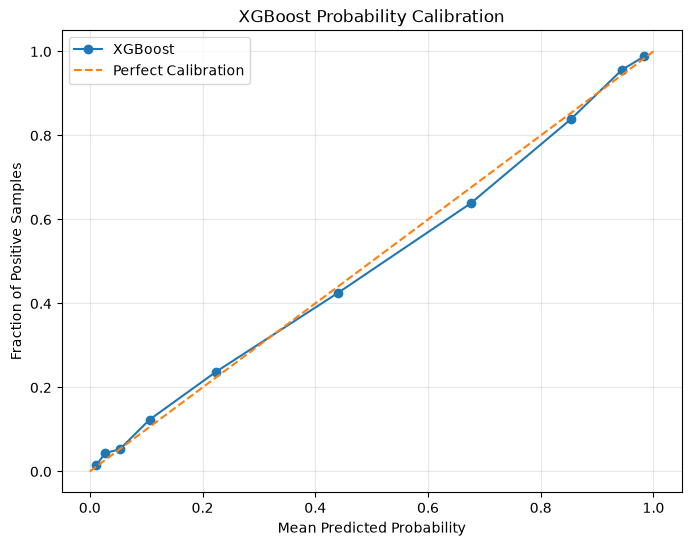

In [42]:
# ============================================================
# XGBOOST PROBABILITY CALIBRATION ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    brier_score_loss,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.calibration import calibration_curve


# ============================================================
# CONFIGURATION
# ============================================================

BEST_PARAMS = {
    "n_estimators": 300,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "eval_metric": "logloss"
}


# ============================================================
# GROUP INFORMATION
# ============================================================

groups = (
    df[feature_columns]
    .astype(str)
    .agg("_".join, axis=1)
)


# ============================================================
# OUT-OF-FOLD PREDICTIONS
# ============================================================

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_probabilities = np.zeros(len(X))
oof_predictions = np.zeros(len(X), dtype=int)


for fold, (train_idx, val_idx) in enumerate(
    cv.split(X, y, groups=groups),
    start=1
):

    print(f"Training calibration fold {fold}/5...")

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = XGBClassifier(**BEST_PARAMS)

    model.fit(
        X_train,
        y_train,
        verbose=False
    )

    probabilities = model.predict_proba(X_val)[:, 1]

    oof_probabilities[val_idx] = probabilities
    oof_predictions[val_idx] = (
        probabilities >= 0.50
    ).astype(int)


# ============================================================
# BRIER SCORE
# ============================================================

brier = brier_score_loss(
    y,
    oof_probabilities
)


# ============================================================
# ROC-AUC
# ============================================================

roc_auc = roc_auc_score(
    y,
    oof_probabilities
)


# ============================================================
# CLASSIFICATION METRICS
# ============================================================

accuracy = accuracy_score(
    y,
    oof_predictions
)

precision = precision_score(
    y,
    oof_predictions,
    zero_division=0
)

recall = recall_score(
    y,
    oof_predictions,
    zero_division=0
)

f1 = f1_score(
    y,
    oof_predictions,
    zero_division=0
)


# ============================================================
# RESULTS
# ============================================================

print("\n" + "=" * 80)
print("===== OUT-OF-FOLD CALIBRATION RESULTS =====")
print("=" * 80)

print(f"Brier Score : {brier:.4f}")
print(f"ROC-AUC     : {roc_auc:.4f}")
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"F1 Score    : {f1:.4f}")


# ============================================================
# CALIBRATION CURVE
# ============================================================

prob_true, prob_pred = calibration_curve(
    y,
    oof_probabilities,
    n_bins=10,
    strategy="quantile"
)


plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positive Samples")

plt.title(
    "XGBoost Probability Calibration"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [43]:
# ============================================================
# FINAL MODEL CONFIGURATION
# ============================================================

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Best configuration selected through 5-fold CV
final_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

print("===== FINAL MODEL CONFIGURATION =====")
print("Model: XGBoost")
print("n_estimators      :", 300)
print("max_depth         :", 3)
print("learning_rate     :", 0.05)
print("subsample         :", 0.8)
print("colsample_bytree  :", 0.8)

# Train on the complete dataset
final_model.fit(X, y)

print("\nFinal model training complete.")

===== FINAL MODEL CONFIGURATION =====
Model: XGBoost
n_estimators      : 300
max_depth         : 3
learning_rate     : 0.05
subsample         : 0.8
colsample_bytree  : 0.8

Final model training complete.


In [44]:
# ============================================================
# FINAL FEATURE IMPORTANCE
# ============================================================

final_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": final_model.feature_importances_
})

final_importance = final_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

print("===== FINAL XGBOOST FEATURE IMPORTANCE =====")
print(final_importance.to_string(index=False))

===== FINAL XGBOOST FEATURE IMPORTANCE =====
                   feature  importance
          eigenvector_cent    0.208611
           clustering_coef    0.193394
               share_photo    0.080526
              n_of_reviews    0.072095
               share_5star    0.063670
  max_days_between_reviews    0.063277
                  w_degree    0.044264
stdev_days_between_reviews    0.038916
  avg_days_between_reviews    0.035451
            std_review_len    0.032080
                  pagerank    0.031423
         avg_review_rating    0.030978
         tfidf_review_body    0.026939
     share_helpful_reviews    0.026814
  min_days_between_reviews    0.026008
               share_1star    0.025555


In [45]:
import os
from pathlib import Path
import pandas as pd
import numpy as np

# ============================================================
# PHASE 3
# FEATURE AVAILABILITY & INFERENCE FEASIBILITY
# ============================================================

PROJECT_ROOT = Path(r"C:\Users\Aman\Desktop\TrustGuard\product_scam_ml")

RAW_DIR = PROJECT_ROOT / "data" / "raw"

AMAZON_METADATA_FILE = (
    RAW_DIR / "amazon_electronics_metadata_sample.parquet"
)

# ============================================================
# HE ET AL. — 16 FEATURES
# ============================================================

HE_FEATURES = [
    "std_review_len",
    "tfidf_review_body",
    "n_of_reviews",
    "avg_review_rating",
    "avg_days_between_reviews",
    "stdev_days_between_reviews",
    "max_days_between_reviews",
    "min_days_between_reviews",
    "share_helpful_reviews",
    "share_1star",
    "share_5star",
    "share_photo",
    "pagerank",
    "eigenvector_cent",
    "w_degree",
    "clustering_coef"
]

print("=" * 80)
print("PHASE 3 — FEATURE AVAILABILITY & INFERENCE FEASIBILITY")
print("=" * 80)


# ============================================================
# 1. CHECK RAW AMAZON METADATA DATASET
# ============================================================

print("\n" + "=" * 80)
print("1. AMAZON PRODUCT METADATA")
print("=" * 80)

if not AMAZON_METADATA_FILE.exists():
    print("ERROR: Amazon metadata file not found:")
    print(AMAZON_METADATA_FILE)
else:

    amazon_df = pd.read_parquet(AMAZON_METADATA_FILE)

    print("\nFile:")
    print(AMAZON_METADATA_FILE)

    print("\nShape:")
    print(amazon_df.shape)

    print("\nColumns:")
    for i, col in enumerate(amazon_df.columns, 1):
        print(f"{i:2}. {col}")

    print("\nDtypes:")
    print(amazon_df.dtypes)

    print("\nSample:")
    print(amazon_df.head(3))


# ============================================================
# 2. SEARCH ENTIRE RAW DATA DIRECTORY
# ============================================================

print("\n" + "=" * 80)
print("2. FILES AVAILABLE IN DATA/RAW")
print("=" * 80)

all_files = []

for path in RAW_DIR.rglob("*"):
    if path.is_file():
        all_files.append(path)

if not all_files:
    print("No files found.")
else:
    for path in sorted(all_files):
        size_mb = path.stat().st_size / (1024 * 1024)
        print(f"{path.relative_to(PROJECT_ROOT)}")
        print(f"    Size: {size_mb:.2f} MB")


# ============================================================
# 3. IDENTIFY REVIEW-LEVEL DATASETS
# ============================================================

print("\n" + "=" * 80)
print("3. REVIEW-LEVEL DATASET DETECTION")
print("=" * 80)

review_candidates = []

# Words that strongly suggest review-level data
review_keywords = [
    "review",
    "reviews",
    "rating",
    "reviewer",
    "reviewer_id",
    "review_id"
]

for path in sorted(all_files):

    suffixes = "".join(path.suffixes).lower()

    # Only inspect common tabular formats
    if not (
        suffixes.endswith(".csv")
        or suffixes.endswith(".csv.gz")
        or suffixes.endswith(".parquet")
    ):
        continue

    try:

        # ----------------------------------------------------
        # Read only schema / columns where possible
        # ----------------------------------------------------

        if suffixes.endswith(".parquet"):

            temp = pd.read_parquet(path)

        else:

            temp = pd.read_csv(
                path,
                nrows=5,
                low_memory=False
            )

        columns_lower = [
            str(c).lower()
            for c in temp.columns
        ]

        matched_keywords = [
            kw for kw in review_keywords
            if any(kw in col for col in columns_lower)
        ]

        if matched_keywords:

            review_candidates.append({
                "file": path,
                "columns": list(temp.columns),
                "matched_keywords": matched_keywords
            })

    except Exception as e:

        print(f"\nCould not inspect: {path}")
        print("Reason:", e)


if not review_candidates:

    print("\nNo obvious review-level datasets detected.")

else:

    print("\nPotential review-level datasets:")

    for item in review_candidates:

        print("\n" + "-" * 70)
        print("FILE:")
        print(item["file"])

        print("\nMatched keywords:")
        print(item["matched_keywords"])

        print("\nColumns:")
        for col in item["columns"]:
            print(" ", col)


# ============================================================
# 4. LOAD EACH POTENTIAL REVIEW DATASET
# ============================================================

print("\n" + "=" * 80)
print("4. REVIEW DATASET STRUCTURE")
print("=" * 80)

loaded_review_datasets = {}

for item in review_candidates:

    path = item["file"]

    try:

        suffixes = "".join(path.suffixes).lower()

        if suffixes.endswith(".parquet"):
            review_df = pd.read_parquet(path)

        else:
            review_df = pd.read_csv(
                path,
                low_memory=False
            )

        dataset_name = path.name

        loaded_review_datasets[dataset_name] = review_df

        print("\n" + "-" * 70)
        print(f"DATASET: {dataset_name}")
        print(f"Shape: {review_df.shape}")

        print("\nColumns:")

        for i, col in enumerate(review_df.columns, 1):
            print(f"{i:2}. {col}")

        print("\nDtypes:")
        print(review_df.dtypes)

        print("\nMissing values:")

        missing = review_df.isna().sum()

        missing = missing[missing > 0].sort_values(
            ascending=False
        )

        if len(missing) == 0:
            print("No missing values.")
        else:
            print(missing)

    except Exception as e:

        print("\nCould not load:", path)
        print("Reason:", e)


# ============================================================
# 5. SEARCH FOR IMPORTANT REVIEW-LEVEL COLUMNS
# ============================================================

print("\n" + "=" * 80)
print("5. REVIEW COLUMN CAPABILITY CHECK")
print("=" * 80)

# We are deliberately NOT assuming exact column names.
# We only look for possible evidence.

COLUMN_PATTERNS = {

    "product_identifier": [
        "product_id",
        "parent_asin",
        "asin",
        "product",
        "item_id"
    ],

    "reviewer_identifier": [
        "reviewer_id",
        "user_id",
        "user",
        "reviewer"
    ],

    "review_text": [
        "review_text",
        "review_body",
        "text",
        "review",
        "body"
    ],

    "rating": [
        "rating",
        "overall",
        "stars",
        "score"
    ],

    "timestamp": [
        "timestamp",
        "review_time",
        "date",
        "review_date",
        "unix_review_time",
        "time"
    ],

    "helpful_votes": [
        "helpful_votes",
        "helpful",
        "helpful_vote",
        "helpful_count"
    ],

    "total_votes": [
        "total_votes",
        "vote_count",
        "votes"
    ],

    "photo": [
        "photo",
        "image",
        "images",
        "image_count"
    ]
}


def find_matching_columns(columns, patterns):

    matches = []

    for col in columns:

        col_lower = str(col).lower()

        for pattern in patterns:

            if pattern in col_lower:
                matches.append(col)
                break

    return matches


for dataset_name, review_df in loaded_review_datasets.items():

    print("\n" + "-" * 70)
    print("DATASET:", dataset_name)

    for capability, patterns in COLUMN_PATTERNS.items():

        matches = find_matching_columns(
            review_df.columns,
            patterns
        )

        if matches:
            print(f"{capability:25} -> {matches}")
        else:
            print(f"{capability:25} -> NOT FOUND")


# ============================================================
# 6. CHECK AMAZON METADATA FOR REVIEW-RELATED INFORMATION
# ============================================================

print("\n" + "=" * 80)
print("6. AMAZON METADATA — REVIEW-RELATED FIELDS")
print("=" * 80)

metadata_review_patterns = [
    "rating",
    "review",
    "helpful",
    "photo",
    "reviewer",
    "date",
    "time"
]

metadata_matches = []

for col in amazon_df.columns:

    col_lower = str(col).lower()

    if any(
        pattern in col_lower
        for pattern in metadata_review_patterns
    ):
        metadata_matches.append(col)

print("\nPotential review-related metadata columns:")

for col in metadata_matches:
    print(" ", col)


# ============================================================
# 7. HE ET AL. FEATURE FEASIBILITY MATRIX
# ============================================================

print("\n" + "=" * 80)
print("7. HE ET AL. FEATURE FEASIBILITY")
print("=" * 80)

# Current Amazon metadata capabilities
metadata_columns = {
    str(c).lower()
    for c in amazon_df.columns
}


def has_any_column(patterns):

    for col in metadata_columns:
        for pattern in patterns:
            if pattern in col:
                return True

    return False


feature_feasibility = {

    "std_review_len": (
        False,
        "Requires review text"
    ),

    "tfidf_review_body": (
        False,
        "Requires review text + TF-IDF processing"
    ),

    "n_of_reviews": (
        False,
        "Requires actual review records or trusted review count"
    ),

    "avg_review_rating": (
        has_any_column(["average_rating"]),
        "Available from product metadata as average rating"
    ),

    "avg_days_between_reviews": (
        False,
        "Requires review timestamps"
    ),

    "stdev_days_between_reviews": (
        False,
        "Requires review timestamps"
    ),

    "max_days_between_reviews": (
        False,
        "Requires review timestamps"
    ),

    "min_days_between_reviews": (
        False,
        "Requires review timestamps"
    ),

    "share_helpful_reviews": (
        False,
        "Requires helpful-vote information at review level"
    ),

    "share_1star": (
        False,
        "Requires individual review ratings"
    ),

    "share_5star": (
        False,
        "Requires individual review ratings"
    ),

    "share_photo": (
        False,
        "Requires review-level photo information"
    ),

    "pagerank": (
        False,
        "Requires reviewer-product interaction graph"
    ),

    "eigenvector_cent": (
        False,
        "Requires reviewer-product interaction graph"
    ),

    "w_degree": (
        False,
        "Requires reviewer-product interaction graph"
    ),

    "clustering_coef": (
        False,
        "Requires reviewer-product interaction graph"
    )
}


print(
    f"\n{'Feature':35} {'Available':12} Explanation"
)

print("-" * 100)

for feature in HE_FEATURES:

    available, explanation = feature_feasibility[feature]

    status = "YES" if available else "NO"

    print(
        f"{feature:35} "
        f"{status:12} "
        f"{explanation}"
    )


# ============================================================
# 8. SUMMARY BY FEATURE CATEGORY
# ============================================================

print("\n" + "=" * 80)
print("8. FEATURE CATEGORY SUMMARY")
print("=" * 80)

categories = {

    "Review Content": [
        "std_review_len",
        "tfidf_review_body"
    ],

    "Review Volume / Rating": [
        "n_of_reviews",
        "avg_review_rating",
        "share_1star",
        "share_5star"
    ],

    "Temporal Behaviour": [
        "avg_days_between_reviews",
        "stdev_days_between_reviews",
        "max_days_between_reviews",
        "min_days_between_reviews"
    ],

    "Review Engagement": [
        "share_helpful_reviews",
        "share_photo"
    ],

    "Reviewer Network": [
        "pagerank",
        "eigenvector_cent",
        "w_degree",
        "clustering_coef"
    ]
}


for category, features in categories.items():

    available_count = sum(
        feature_feasibility[f][0]
        for f in features
    )

    print(
        f"{category:25} : "
        f"{available_count}/{len(features)} directly available"
    )


# ============================================================
# 9. FINAL ARCHITECTURAL CONCLUSION
# ============================================================

print("\n" + "=" * 80)
print("9. ARCHITECTURAL INTERPRETATION")
print("=" * 80)

print("""
The purpose of this analysis is NOT to force the production
Amazon metadata into He et al.'s feature space.

Instead:

RESEARCH BENCHMARK
------------------
Use the original He et al. dataset with its complete 16-feature
representation to reproduce and evaluate the academic benchmark.

PRODUCTION INFERENCE
--------------------
Use only features that can genuinely be computed from the
runtime inputs available to TrustGuard.

NO PSEUDO-MAPPINGS
------------------
Do NOT treat:

rating_number      -> n_of_reviews
average_rating     -> share_5star
product metadata   -> review temporal statistics
product metadata   -> reviewer network statistics

as equivalent features.

Those would change the meaning of the original features and
would weaken the methodological validity of the system.

The final production feature set should therefore be determined
AFTER inspecting the actual review-level data available in the
workspace.
""")

PHASE 3 — FEATURE AVAILABILITY & INFERENCE FEASIBILITY

1. AMAZON PRODUCT METADATA

File:
C:\Users\Aman\Desktop\TrustGuard\product_scam_ml\data\raw\amazon_electronics_metadata_sample.parquet

Shape:
(10000, 16)

Columns:
 1. main_category
 2. title
 3. average_rating
 4. rating_number
 5. features
 6. description
 7. price
 8. images
 9. videos
10. store
11. categories
12. details
13. parent_asin
14. bought_together
15. subtitle
16. author

Dtypes:
main_category          str
title                  str
average_rating     float64
rating_number        int64
features            object
description         object
price                  str
images              object
videos              object
store                  str
categories          object
details                str
parent_asin            str
bought_together        str
subtitle               str
author                 str
dtype: object

Sample:
     main_category                                              title  \
0  All Electronics 

In [47]:
import os
import ast
import json
import re
import warnings

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

# ============================================================
# PATHS
# ============================================================

BASE_DIR = r"C:\Users\Aman\Desktop\TrustGuard\product_scam_ml"

REVIEW_PATH = os.path.join(
    BASE_DIR,
    "data",
    "raw",
    "he_associated_review_data",
    "public_reviews_dataset_cleaned.csv"
)

METADATA_PATH = os.path.join(
    BASE_DIR,
    "data",
    "raw",
    "amazon_electronics_metadata_sample.parquet"
)

REPORT_DIR = os.path.join(BASE_DIR, "reports")
OUTPUT_DIR = os.path.join(BASE_DIR, "data", "processed")

os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Review dataset:")
print(REVIEW_PATH)

print("\nMetadata dataset:")
print(METADATA_PATH)

print("\nReport directory:")
print(REPORT_DIR)

print("\nOutput directory:")
print(OUTPUT_DIR)

Review dataset:
C:\Users\Aman\Desktop\TrustGuard\product_scam_ml\data\raw\he_associated_review_data\public_reviews_dataset_cleaned.csv

Metadata dataset:
C:\Users\Aman\Desktop\TrustGuard\product_scam_ml\data\raw\amazon_electronics_metadata_sample.parquet

Report directory:
C:\Users\Aman\Desktop\TrustGuard\product_scam_ml\reports

Output directory:
C:\Users\Aman\Desktop\TrustGuard\product_scam_ml\data\processed


In [48]:
print("=" * 80)
print("LOADING DATASETS")
print("=" * 80)

reviews = pd.read_csv(REVIEW_PATH)
metadata = pd.read_parquet(METADATA_PATH)

print("\n===== REVIEW DATASET =====")
print("Shape:", reviews.shape)

print("\nColumns:")
for i, col in enumerate(reviews.columns, 1):
    print(f"{i:2}. {col}")

print("\n===== AMAZON METADATA =====")
print("Shape:", metadata.shape)

print("\nColumns:")
for i, col in enumerate(metadata.columns, 1):
    print(f"{i:2}. {col}")

LOADING DATASETS

===== REVIEW DATASET =====
Shape: (381734, 23)

Columns:
 1. asin
 2. review_id
 3. reviewer_id
 4. review_title
 5. review_text
 6. review_rating
 7. review_date
 8. product_title
 9. product_url
10. number_of_helpful
11. number_of_photos
12. photo_thumbnail_urls
13. photo_fullsize_urls
14. asin_url
15. review_url
16. reviewer_url
17. fake_review_campaign_start_date
18. fake_review_product
19. reviewer_classified_fake
20. reviewer_classified_honest
21. reviewer_labeled_fake
22. reviewer_labeled_honest
23. review_is_removed_by_amazon

===== AMAZON METADATA =====
Shape: (10000, 16)

Columns:
 1. main_category
 2. title
 3. average_rating
 4. rating_number
 5. features
 6. description
 7. price
 8. images
 9. videos
10. store
11. categories
12. details
13. parent_asin
14. bought_together
15. subtitle
16. author


In [49]:
print("=" * 80)
print("IDENTIFIER VALIDATION")
print("=" * 80)

required_review_columns = [
    "asin",
    "review_id",
    "reviewer_id",
    "review_text",
    "review_rating",
    "review_date",
    "number_of_helpful",
    "number_of_photos",
    "fake_review_product"
]

required_metadata_columns = [
    "parent_asin",
    "title",
    "average_rating",
    "rating_number",
    "features",
    "description",
    "price",
    "images",
    "videos",
    "store",
    "categories"
]

missing_review_columns = [
    c for c in required_review_columns
    if c not in reviews.columns
]

missing_metadata_columns = [
    c for c in required_metadata_columns
    if c not in metadata.columns
]

print("\nMissing review columns:")
print(missing_review_columns if missing_review_columns else "NONE")

print("\nMissing metadata columns:")
print(missing_metadata_columns if missing_metadata_columns else "NONE")

assert not missing_review_columns, \
    f"Review dataset is missing required columns: {missing_review_columns}"

assert not missing_metadata_columns, \
    f"Metadata dataset is missing required columns: {missing_metadata_columns}"

IDENTIFIER VALIDATION

Missing review columns:
NONE

Missing metadata columns:
NONE


In [50]:
print("=" * 80)
print("CLEANING PRODUCT IDENTIFIERS")
print("=" * 80)

reviews["asin"] = reviews["asin"].astype("string").str.strip()
metadata["parent_asin"] = metadata["parent_asin"].astype("string").str.strip()

reviews = reviews[
    reviews["asin"].notna() &
    (reviews["asin"] != "")
].copy()

metadata = metadata[
    metadata["parent_asin"].notna() &
    (metadata["parent_asin"] != "")
].copy()

print("Unique review products:")
print(reviews["asin"].nunique())

print("Unique metadata products:")
print(metadata["parent_asin"].nunique())

print("Duplicate metadata ASIN rows:")
print(metadata["parent_asin"].duplicated().sum())

CLEANING PRODUCT IDENTIFIERS
Unique review products:
3389
Unique metadata products:
10000
Duplicate metadata ASIN rows:
0


In [51]:
print("=" * 80)
print("PRODUCT-LEVEL GROUND TRUTH VALIDATION")
print("=" * 80)

label_consistency = (
    reviews
    .groupby("asin")["fake_review_product"]
    .nunique()
)

inconsistent_products = label_consistency[
    label_consistency > 1
]

print("Unique products:", len(label_consistency))
print("Products with inconsistent labels:", len(inconsistent_products))

if len(inconsistent_products) == 0:
    print("\nGROUND TRUTH: PASS")
else:
    print("\nGROUND TRUTH: FAIL")
    print(inconsistent_products.head())

# One product-level label
product_labels = (
    reviews
    .groupby("asin", as_index=False)["fake_review_product"]
    .first()
)

product_labels["fake_review_product"] = (
    product_labels["fake_review_product"].astype(int)
)

print("\nProduct-level label distribution:")
print(product_labels["fake_review_product"].value_counts())

print("\nProduct-level proportions:")
print(
    product_labels["fake_review_product"]
    .value_counts(normalize=True)
    .round(4)
)

PRODUCT-LEVEL GROUND TRUTH VALIDATION
Unique products: 3389
Products with inconsistent labels: 0

GROUND TRUTH: PASS

Product-level label distribution:
fake_review_product
0    1895
1    1494
Name: count, dtype: int64

Product-level proportions:
fake_review_product
0    0.5592
1    0.4408
Name: proportion, dtype: float64


In [52]:
print("=" * 80)
print("PRODUCT-LEVEL REVIEW AGGREGATION")
print("=" * 80)

reviews["review_date_parsed"] = pd.to_datetime(
    reviews["review_date"],
    errors="coerce"
)

review_agg = (
    reviews
    .groupby("asin")
    .agg(
        actual_review_count=("review_id", "nunique"),
        review_rating_mean=("review_rating", "mean"),
        review_helpful_mean=("number_of_helpful", "mean"),
        review_photo_mean=("number_of_photos", "mean"),
        reviewer_count=("reviewer_id", "nunique"),
        review_date_min=("review_date_parsed", "min"),
        review_date_max=("review_date_parsed", "max")
    )
    .reset_index()
)

print("Review aggregate shape:", review_agg.shape)

print("\nSample:")
display(review_agg.head())

PRODUCT-LEVEL REVIEW AGGREGATION
Review aggregate shape: (3389, 8)

Sample:


,asin,actual_review_count,review_rating_mean,review_helpful_mean,review_photo_mean,reviewer_count,review_date_min,review_date_max
0,1099134587,4,2.750000,0.000000,0.000000,4,2019-10-16,2019-12-28
1,1523503033,7,3.142857,0.428571,0.000000,7,2019-01-15,2020-01-26
2,1698481225,1,5.000000,1.000000,0.000000,1,2020-02-16,2020-02-16
3,B00003008E,302,2.350993,0.696667,0.083333,302,2009-06-24,2020-10-07
4,B00004OCJQ,233,3.206009,2.629310,0.034483,233,2003-12-10,2020-12-28


In [53]:
print("=" * 80)
print("JOINING PRODUCT METADATA + LABELS")
print("=" * 80)

metadata_subset = metadata[
    [
        "parent_asin",
        "title",
        "average_rating",
        "rating_number",
        "features",
        "description",
        "price",
        "images",
        "videos",
        "store",
        "categories"
    ]
].copy()

metadata_subset = metadata_subset.rename(
    columns={"parent_asin": "asin"}
)

# Metadata should have one row per ASIN.
metadata_subset = metadata_subset.drop_duplicates(
    subset=["asin"],
    keep="first"
)

products = (
    product_labels
    .merge(
        metadata_subset,
        on="asin",
        how="left",
        validate="one_to_one"
    )
    .merge(
        review_agg,
        on="asin",
        how="left",
        validate="one_to_one"
    )
)

print("Final product-level shape:", products.shape)

print("\nProducts with metadata match:")
print(products["title"].notna().sum())

print("Products without metadata match:")
print(products["title"].isna().sum())

print(
    "\nMetadata coverage:",
    round(products["title"].notna().mean() * 100, 2),
    "%"
)

JOINING PRODUCT METADATA + LABELS
Final product-level shape: (3389, 19)

Products with metadata match:
1
Products without metadata match:
3388

Metadata coverage: 0.03 %


In [55]:
print("=" * 80)
print("UTILITY FUNCTIONS")
print("=" * 80)

def safe_parse(value):
    """
    Convert Amazon nested fields stored as:
    - Python lists
    - Python dictionaries
    - string representations of lists/dicts
    - NaN/None
    into Python objects.
    """

    if value is None:
        return None

    if isinstance(value, float) and np.isnan(value):
        return None

    if isinstance(value, (list, dict, tuple)):
        return value

    if isinstance(value, str):
        value = value.strip()

        if value == "":
            return None

        try:
            return ast.literal_eval(value)
        except Exception:
            return value

    return value


def count_nested_items(value):
    """
    Count items in Amazon list/dict structures.
    """

    value = safe_parse(value)

    if value is None:
        return 0

    if isinstance(value, (list, tuple, set)):
        return len(value)

    if isinstance(value, dict):
        total = 0

        for v in value.values():
            if isinstance(v, (list, tuple, set)):
                total += len(v)

        return total

    return 0


def text_from_nested(value):
    """
    Convert Amazon nested feature structures into text.
    """

    value = safe_parse(value)

    if value is None:
        return ""

    if isinstance(value, str):
        return value

    if isinstance(value, (list, tuple)):
        return " ".join(
            str(x)
            for x in value
            if x is not None
        )

    if isinstance(value, dict):
        return " ".join(
            str(v)
            for v in value.values()
            if v is not None
        )

    return str(value)


def word_count(text):
    if not isinstance(text, str):
        return 0

    return len(
        re.findall(r"\b\w+\b", text, flags=re.UNICODE)
    )


def safe_price(value):
    """
    Extract numeric price from Amazon price strings.
    Examples:
        '$19.99' -> 19.99
        '19.99'  -> 19.99
        None     -> NaN
    """

    if value is None:
        return np.nan

    if isinstance(value, float) and np.isnan(value):
        return np.nan

    text = str(value).strip()

    if text == "":
        return np.nan

    # Remove currency symbols and retain numeric structure.
    match = re.search(
        r"-?\d[\d,]*(?:\.\d+)?",
        text
    )

    if not match:
        return np.nan

    number = match.group(0).replace(",", "")

    try:
        return float(number)
    except Exception:
        return np.nan

UTILITY FUNCTIONS


In [56]:
print("=" * 80)
print("DERIVING 26 TRUSTGUARD FEATURES")
print("=" * 80)

# ============================================================
# TEXT FEATURES
# ============================================================

products["title_clean"] = (
    products["title"]
    .fillna("")
    .astype(str)
)

products["description_clean"] = (
    products["description"]
    .apply(text_from_nested)
)

products["features_clean"] = (
    products["features"]
    .apply(text_from_nested)
)

products["title_length"] = (
    products["title_clean"].str.len()
)

products["title_word_count"] = (
    products["title_clean"].apply(word_count)
)

products["uppercase_ratio"] = (
    products["title_clean"]
    .apply(
        lambda x:
        sum(c.isupper() for c in x) / len(x)
        if len(x) > 0 else 0
    )
)

products["special_character_ratio"] = (
    products["title_clean"]
    .apply(
        lambda x:
        sum(
            not c.isalnum() and not c.isspace()
            for c in x
        ) / len(x)
        if len(x) > 0 else 0
    )
)

products["description_length"] = (
    products["description_clean"].str.len()
)

products["description_word_count"] = (
    products["description_clean"].apply(word_count)
)

# ============================================================
# FEATURE-LIST FEATURES
# ============================================================

products["feature_count"] = (
    products["features"]
    .apply(count_nested_items)
)

products["feature_text_length"] = (
    products["features_clean"].str.len()
)

# ============================================================
# CATEGORY
# ============================================================

products["category_count"] = (
    products["categories"]
    .apply(count_nested_items)
)

# ============================================================
# IMAGE / VIDEO
# ============================================================

products["image_count"] = (
    products["images"]
    .apply(count_nested_items)
)

products["video_count"] = (
    products["videos"]
    .apply(count_nested_items)
)

products["has_videos"] = (
    products["video_count"] > 0
).astype(int)

# ============================================================
# SELLER
# ============================================================

products["seller_missing"] = (
    products["store"].isna() |
    (
        products["store"]
        .astype(str)
        .str.strip()
        .isin(["", "nan", "None"])
    )
).astype(int)

products["seller_name_length"] = (
    products["store"]
    .fillna("")
    .astype(str)
    .str.len()
)

# ============================================================
# PRICE
# ============================================================

products["price_numeric"] = (
    products["price"]
    .apply(safe_price)
)

products["price_missing"] = (
    products["price_numeric"].isna()
).astype(int)

# ============================================================
# RATING
# ============================================================

products["average_rating"] = pd.to_numeric(
    products["average_rating"],
    errors="coerce"
)

products["rating_number"] = pd.to_numeric(
    products["rating_number"],
    errors="coerce"
)

products["log_rating_number"] = np.log1p(
    products["rating_number"].clip(lower=0)
)

# Distance from neutral midpoint 3.0
products["rating_extremeness"] = (
    (products["average_rating"] - 3.0).abs()
)

products["high_rating"] = (
    products["average_rating"] >= 4.5
).astype(int)

products["low_review_count"] = (
    products["rating_number"] <= 10
).astype(int)

products["high_rating_low_reviews"] = (
    (
        products["average_rating"] >= 4.5
    ) &
    (
        products["rating_number"] <= 10
    )
).astype(int)

DERIVING 26 TRUSTGUARD FEATURES


In [57]:
print("=" * 80)
print("CREATING CATEGORY KEY")
print("=" * 80)


def category_key(value):
    value = safe_parse(value)

    if value is None:
        return "UNKNOWN"

    if isinstance(value, (list, tuple)):
        parts = [
            str(x).strip()
            for x in value
            if x is not None and str(x).strip()
        ]

        if not parts:
            return "UNKNOWN"

        # Use the complete normalized category path.
        return " > ".join(parts).lower()

    if isinstance(value, str):
        value = value.strip()

        if not value:
            return "UNKNOWN"

        return value.lower()

    return str(value).lower()


products["category_key"] = (
    products["categories"]
    .apply(category_key)
)

print(
    "Unique category groups:",
    products["category_key"].nunique()
)

CREATING CATEGORY KEY
Unique category groups: 2


In [58]:
print("=" * 80)
print("LEAKAGE-SAFE PRODUCT SPLIT")
print("=" * 80)

train_df, test_df = train_test_split(
    products,
    test_size=0.20,
    random_state=42,
    stratify=products["fake_review_product"]
)

print("Training products:", len(train_df))
print("Testing products :", len(test_df))

print("\nTraining label distribution:")
print(
    train_df["fake_review_product"]
    .value_counts(normalize=True)
    .round(4)
)

print("\nTesting label distribution:")
print(
    test_df["fake_review_product"]
    .value_counts(normalize=True)
    .round(4)
)

LEAKAGE-SAFE PRODUCT SPLIT
Training products: 2711
Testing products : 678

Training label distribution:
fake_review_product
0    0.5592
1    0.4408
Name: proportion, dtype: float64

Testing label distribution:
fake_review_product
0    0.559
1    0.441
Name: proportion, dtype: float64


In [59]:
print("=" * 80)
print("LEARNING CATEGORY PRICE STATISTICS FROM TRAINING DATA")
print("=" * 80)

train_price = train_df[
    train_df["price_numeric"].notna()
].copy()

category_price_stats = (
    train_price
    .groupby("category_key")["price_numeric"]
    .agg(
        category_price_count="count",
        category_price_median="median"
    )
    .reset_index()
)

# Calculate MAD separately.
category_mad = (
    train_price
    .groupby("category_key")["price_numeric"]
    .apply(
        lambda x:
        np.median(
            np.abs(x - np.median(x))
        )
    )
    .reset_index(name="category_price_mad")
)

category_price_stats = (
    category_price_stats
    .merge(
        category_mad,
        on="category_key",
        how="left"
    )
)

print(
    "Categories with training price statistics:",
    len(category_price_stats)
)

print("\nSample:")
display(category_price_stats.head())

LEARNING CATEGORY PRICE STATISTICS FROM TRAINING DATA
Categories with training price statistics: 1

Sample:


,category_key,category_price_count,category_price_median,category_price_mad
0,"['electronics' 'household batteries, chargers ...",1,27.94,0.0


In [60]:
print("=" * 80)
print("APPLYING LEAKAGE-SAFE CATEGORY PRICE FEATURES")
print("=" * 80)


def apply_price_features(df, category_stats):

    out = df.copy()

    out = out.merge(
        category_stats,
        on="category_key",
        how="left"
    )

    valid_reference = (
        out["category_price_median"].notna() &
        (out["category_price_median"] > 0)
    )

    price_ratio = np.full(
        len(out),
        np.nan
    )

    price_ratio[valid_reference] = (
        out.loc[valid_reference, "price_numeric"]
        /
        out.loc[valid_reference, "category_price_median"]
    )

    out["price_ratio_to_category"] = price_ratio

    out["log_price_ratio"] = np.log(
        out["price_ratio_to_category"]
    )

    epsilon = 1e-9

    valid_mad = (
        valid_reference &
        out["category_price_mad"].notna() &
        (out["category_price_mad"] > epsilon)
    )

    anomaly = np.full(
        len(out),
        np.nan
    )

    anomaly[valid_mad] = (
        (
            out.loc[valid_mad, "price_numeric"]
            -
            out.loc[valid_mad, "category_price_median"]
        ).abs()
        /
        (
            out.loc[valid_mad, "category_price_mad"]
            + epsilon
        )
    )

    out["price_anomaly"] = anomaly

    return out


train_features = apply_price_features(
    train_df,
    category_price_stats
)

test_features = apply_price_features(
    test_df,
    category_price_stats
)

print("Training features:", train_features.shape)
print("Testing features :", test_features.shape)

APPLYING LEAKAGE-SAFE CATEGORY PRICE FEATURES
Training features: (2711, 50)
Testing features : (678, 50)


In [61]:
print("=" * 80)
print("RECOMBINING PRODUCT DATA")
print("=" * 80)

train_features["split"] = "train"
test_features["split"] = "test"

products_final = pd.concat(
    [
        train_features,
        test_features
    ],
    axis=0
)

products_final = products_final.sort_index()

print(
    "Final product dataset:",
    products_final.shape
)

print(
    "Training rows:",
    (products_final["split"] == "train").sum()
)

print(
    "Testing rows:",
    (products_final["split"] == "test").sum()
)

RECOMBINING PRODUCT DATA
Final product dataset: (3389, 51)
Training rows: 2711
Testing rows: 678


In [62]:
print("=" * 80)
print("TRUSTGUARD 26-FEATURE TAXONOMY")
print("=" * 80)

FEATURE_COLUMNS = [
    "title_length",
    "title_word_count",
    "uppercase_ratio",
    "special_character_ratio",

    "description_length",
    "description_word_count",

    "feature_count",
    "feature_text_length",

    "category_count",

    "image_count",
    "video_count",
    "has_videos",

    "seller_missing",
    "seller_name_length",

    "price_numeric",
    "price_missing",

    "price_ratio_to_category",
    "log_price_ratio",
    "price_anomaly",

    "average_rating",
    "rating_number",
    "log_rating_number",

    "rating_extremeness",
    "high_rating",
    "low_review_count",
    "high_rating_low_reviews"
]

print("Total features:", len(FEATURE_COLUMNS))

for i, feature in enumerate(FEATURE_COLUMNS, 1):
    print(f"{i:2}. {feature}")

assert len(FEATURE_COLUMNS) == 26

TRUSTGUARD 26-FEATURE TAXONOMY
Total features: 26
 1. title_length
 2. title_word_count
 3. uppercase_ratio
 4. special_character_ratio
 5. description_length
 6. description_word_count
 7. feature_count
 8. feature_text_length
 9. category_count
10. image_count
11. video_count
12. has_videos
13. seller_missing
14. seller_name_length
15. price_numeric
16. price_missing
17. price_ratio_to_category
18. log_price_ratio
19. price_anomaly
20. average_rating
21. rating_number
22. log_rating_number
23. rating_extremeness
24. high_rating
25. low_review_count
26. high_rating_low_reviews


In [63]:
print("=" * 80)
print("26-FEATURE QUALITY AUDIT")
print("=" * 80)

audit_rows = []

for feature in FEATURE_COLUMNS:

    series = products_final[feature]

    missing_count = series.isna().sum()
    missing_pct = (
        missing_count /
        len(series) *
        100
    )

    infinite_count = 0

    if pd.api.types.is_numeric_dtype(series):
        infinite_count = np.isinf(
            series.dropna()
        ).sum()

    valid_count = (
        len(series)
        - missing_count
        - infinite_count
    )

    unique_count = series.nunique(
        dropna=True
    )

    if valid_count > 0:
        min_value = series.min()
        max_value = series.max()
    else:
        min_value = np.nan
        max_value = np.nan

    audit_rows.append({
        "feature": feature,
        "dtype": str(series.dtype),
        "valid_count": valid_count,
        "missing_count": missing_count,
        "missing_pct": round(missing_pct, 2),
        "infinite_count": infinite_count,
        "unique_count": unique_count,
        "min": min_value,
        "max": max_value
    })

feature_audit = pd.DataFrame(audit_rows)

display(feature_audit)

26-FEATURE QUALITY AUDIT


,feature,dtype,valid_count,missing_count,missing_pct,infinite_count,unique_count,min,max
0,title_length,int64,3389,0,0.00,0,2,0.000000,197.000000
1,title_word_count,int64,3389,0,0.00,0,2,0.000000,30.000000
2,uppercase_ratio,float64,3389,0,0.00,0,2,0.000000,0.157360
3,special_character_ratio,float64,3389,0,0.00,0,2,0.000000,0.030457
4,description_length,int64,3389,0,0.00,0,2,0.000000,2.000000
5,description_word_count,int64,3389,0,0.00,0,1,0.000000,0.000000
6,feature_count,int64,3389,0,0.00,0,1,0.000000,0.000000
7,feature_text_length,int64,3389,0,0.00,0,2,0.000000,1912.000000
8,category_count,int64,3389,0,0.00,0,1,0.000000,0.000000
9,image_count,int64,3389,0,0.00,0,1,0.000000,0.000000


In [64]:
print("=" * 80)
print("FEATURE QUALITY CLASSIFICATION")
print("=" * 80)


def classify_feature(row):

    if row["valid_count"] == 0:
        return "UNUSABLE"

    if row["missing_pct"] > 50:
        return "HIGH_MISSINGNESS"

    if row["missing_pct"] > 20:
        return "MODERATE_MISSINGNESS"

    if row["unique_count"] <= 1:
        return "CONSTANT"

    if row["infinite_count"] > 0:
        return "INVALID_INFINITY"

    return "USABLE"


feature_audit["quality_status"] = (
    feature_audit.apply(
        classify_feature,
        axis=1
    )
)

print(
    feature_audit[
        [
            "feature",
            "missing_pct",
            "unique_count",
            "quality_status"
        ]
    ].to_string(index=False)
)

FEATURE QUALITY CLASSIFICATION
                feature  missing_pct  unique_count   quality_status
           title_length         0.00             2           USABLE
       title_word_count         0.00             2           USABLE
        uppercase_ratio         0.00             2           USABLE
special_character_ratio         0.00             2           USABLE
     description_length         0.00             2           USABLE
 description_word_count         0.00             1         CONSTANT
          feature_count         0.00             1         CONSTANT
    feature_text_length         0.00             2           USABLE
         category_count         0.00             1         CONSTANT
            image_count         0.00             1         CONSTANT
            video_count         0.00             1         CONSTANT
             has_videos         0.00             1         CONSTANT
         seller_missing         0.00             2           USABLE
     seller_name_

In [65]:
print("=" * 80)
print("CATEGORY-DEPENDENT PRICE FEATURE AUDIT")
print("=" * 80)

price_features = [
    "price_ratio_to_category",
    "log_price_ratio",
    "price_anomaly"
]

for feature in price_features:

    train_missing = (
        train_features[feature]
        .isna()
        .mean() * 100
    )

    test_missing = (
        test_features[feature]
        .isna()
        .mean() * 100
    )

    print(f"\n{feature}")
    print(
        f"  Training missing: {train_missing:.2f}%"
    )
    print(
        f"  Testing missing : {test_missing:.2f}%"
    )

CATEGORY-DEPENDENT PRICE FEATURE AUDIT

price_ratio_to_category
  Training missing: 99.96%
  Testing missing : 100.00%

log_price_ratio
  Training missing: 99.96%
  Testing missing : 100.00%

price_anomaly
  Training missing: 100.00%
  Testing missing : 100.00%


In [66]:
print("=" * 80)
print("SEMANTIC / RANGE VALIDATION")
print("=" * 80)

range_checks = {
    "uppercase_ratio": (0, 1),
    "special_character_ratio": (0, 1),
    "rating_extremeness": (0, 2),
    "average_rating": (0, 5),
    "rating_number": (0, np.inf),
    "log_rating_number": (0, np.inf),
    "title_length": (0, np.inf),
    "title_word_count": (0, np.inf),
    "description_length": (0, np.inf),
    "description_word_count": (0, np.inf),
    "feature_count": (0, np.inf),
    "feature_text_length": (0, np.inf),
    "category_count": (0, np.inf),
    "image_count": (0, np.inf),
    "video_count": (0, np.inf),
    "seller_name_length": (0, np.inf),
    "price_numeric": (0, np.inf),
    "log_price_ratio": (-np.inf, np.inf),
    "price_anomaly": (0, np.inf)
}

range_results = []

for feature, (lower, upper) in range_checks.items():

    if feature not in products_final.columns:
        continue

    values = products_final[feature].dropna()

    invalid = (
        (values < lower) |
        (values > upper)
    ).sum()

    range_results.append({
        "feature": feature,
        "invalid_values": int(invalid),
        "invalid_pct": round(
            invalid / len(values) * 100
            if len(values) > 0 else 0,
            3
        )
    })

range_audit = pd.DataFrame(
    range_results
)

display(range_audit)

SEMANTIC / RANGE VALIDATION


,feature,invalid_values,invalid_pct
0,uppercase_ratio,0,0.0
1,special_character_ratio,0,0.0
2,rating_extremeness,0,0.0
3,average_rating,0,0.0
4,rating_number,0,0.0
5,log_rating_number,0,0.0
6,title_length,0,0.0
7,title_word_count,0,0.0
8,description_length,0,0.0
9,description_word_count,0,0.0


In [67]:
print("=" * 80)
print("TARGET LEAKAGE CHECK")
print("=" * 80)

correlation_rows = []

target = products_final[
    "fake_review_product"
].astype(int)

for feature in FEATURE_COLUMNS:

    values = products_final[feature]

    if not pd.api.types.is_numeric_dtype(values):
        continue

    valid = (
        values.notna() &
        np.isfinite(values)
    )

    if valid.sum() < 2:
        corr = np.nan
    else:
        corr = values[valid].corr(
            target[valid]
        )

    correlation_rows.append({
        "feature": feature,
        "target_correlation": corr
    })

leakage_audit = (
    pd.DataFrame(correlation_rows)
    .sort_values(
        "target_correlation",
        key=lambda x: x.abs(),
        ascending=False
    )
)

display(leakage_audit)

TARGET LEAKAGE CHECK


,feature,target_correlation
23,high_rating,-0.015255
4,description_length,-0.015255
3,special_character_ratio,-0.015255
7,feature_text_length,-0.015255
13,seller_name_length,-0.015255
2,uppercase_ratio,-0.015255
1,title_word_count,-0.015255
0,title_length,-0.015255
12,seller_missing,0.015255
15,price_missing,0.015255


In [68]:
print("=" * 80)
print("PRODUCT-LEVEL DUPLICATE AUDIT")
print("=" * 80)

feature_duplicates = products_final[
    FEATURE_COLUMNS
].duplicated()

print(
    "Duplicate feature rows:",
    feature_duplicates.sum()
)

print(
    "Duplicate percentage:",
    round(
        feature_duplicates.mean() * 100,
        3
    ),
    "%"
)

print(
    "\nDuplicate ASINs:",
    products_final["asin"].duplicated().sum()
)

PRODUCT-LEVEL DUPLICATE AUDIT
Duplicate feature rows: 3387
Duplicate percentage: 99.941 %

Duplicate ASINs: 0


In [69]:
print("=" * 80)
print("SAVING DERIVED FEATURE DATASET")
print("=" * 80)

output_columns = [
    "asin",
    "fake_review_product",
    "split"
] + FEATURE_COLUMNS

final_feature_path = os.path.join(
    OUTPUT_DIR,
    "phase4b_product_metadata_features.csv"
)

products_final[
    output_columns
].to_csv(
    final_feature_path,
    index=False
)

print(
    "Saved:",
    final_feature_path
)

SAVING DERIVED FEATURE DATASET
Saved: C:\Users\Aman\Desktop\TrustGuard\product_scam_ml\data\processed\phase4b_product_metadata_features.csv


In [70]:
print("=" * 80)
print("SAVING AUDIT REPORTS")
print("=" * 80)

feature_audit_path = os.path.join(
    REPORT_DIR,
    "phase4b_feature_quality_audit.csv"
)

range_audit_path = os.path.join(
    REPORT_DIR,
    "phase4b_feature_range_audit.csv"
)

leakage_audit_path = os.path.join(
    REPORT_DIR,
    "phase4b_target_correlation_audit.csv"
)

category_stats_path = os.path.join(
    REPORT_DIR,
    "phase4b_training_category_price_stats.csv"
)

feature_audit.to_csv(
    feature_audit_path,
    index=False
)

range_audit.to_csv(
    range_audit_path,
    index=False
)

leakage_audit.to_csv(
    leakage_audit_path,
    index=False
)

category_price_stats.to_csv(
    category_stats_path,
    index=False
)

print("Saved:")
print(feature_audit_path)
print(range_audit_path)
print(leakage_audit_path)
print(category_stats_path)

SAVING AUDIT REPORTS
Saved:
C:\Users\Aman\Desktop\TrustGuard\product_scam_ml\reports\phase4b_feature_quality_audit.csv
C:\Users\Aman\Desktop\TrustGuard\product_scam_ml\reports\phase4b_feature_range_audit.csv
C:\Users\Aman\Desktop\TrustGuard\product_scam_ml\reports\phase4b_target_correlation_audit.csv
C:\Users\Aman\Desktop\TrustGuard\product_scam_ml\reports\phase4b_training_category_price_stats.csv


In [71]:
print("=" * 80)
print("PHASE 4B — FINAL AUDIT SUMMARY")
print("=" * 80)

total_features = len(FEATURE_COLUMNS)

usable_features = (
    feature_audit["quality_status"]
    .eq("USABLE")
    .sum()
)

moderate_missing = (
    feature_audit["quality_status"]
    .eq("MODERATE_MISSINGNESS")
    .sum()
)

high_missing = (
    feature_audit["quality_status"]
    .eq("HIGH_MISSINGNESS")
    .sum()
)

unusable = (
    feature_audit["quality_status"]
    .isin(
        [
            "UNUSABLE",
            "CONSTANT",
            "INVALID_INFINITY"
        ]
    )
    .sum()
)

metadata_match = (
    products["title"].notna().mean() * 100
)

print(f"""
Dataset
-------
Review rows                  : {len(reviews):,}
Labeled products             : {len(product_labels):,}
Metadata rows                : {len(metadata):,}
Products with metadata match : {metadata_match:.2f}%

Ground Truth
------------
Label                       : fake_review_product
Product-level consistency   : PASS
Fake products               : {product_labels["fake_review_product"].sum():,}
Genuine products             : {(product_labels["fake_review_product"] == 0).sum():,}

TrustGuard Feature Space
------------------------
Total features              : {total_features}
Usable features             : {usable_features}
Moderate missingness        : {moderate_missing}
High missingness            : {high_missing}
Unusable                    : {unusable}

Price Features
--------------
Category statistics learned : TRAINING DATA ONLY
Price ratio                 : derived
Log price ratio             : derived
Price anomaly               : derived

Leakage Prevention
------------------
Category price statistics   : TRAIN ONLY
Test labels used for stats  : NO
Test prices used for stats  : NO
Target used in feature calc : NO
""")

print("=" * 80)
print("FEATURE QUALITY TABLE")
print("=" * 80)

display(
    feature_audit[
        [
            "feature",
            "missing_pct",
            "unique_count",
            "quality_status"
        ]
    ]
)

PHASE 4B — FINAL AUDIT SUMMARY

Dataset
-------
Review rows                  : 381,734
Labeled products             : 3,389
Metadata rows                : 10,000
Products with metadata match : 0.03%

Ground Truth
------------
Label                       : fake_review_product
Product-level consistency   : PASS
Fake products               : 1,494
Genuine products             : 1,895

TrustGuard Feature Space
------------------------
Total features              : 26
Usable features             : 10
Moderate missingness        : 0
High missingness            : 7
Unusable                    : 9

Price Features
--------------
Category statistics learned : TRAINING DATA ONLY
Price ratio                 : derived
Log price ratio             : derived
Price anomaly               : derived

Leakage Prevention
------------------
Category price statistics   : TRAIN ONLY
Test labels used for stats  : NO
Test prices used for stats  : NO
Target used in feature calc : NO

FEATURE QUALITY TABLE


,feature,missing_pct,unique_count,quality_status
0,title_length,0.00,2,USABLE
1,title_word_count,0.00,2,USABLE
2,uppercase_ratio,0.00,2,USABLE
3,special_character_ratio,0.00,2,USABLE
4,description_length,0.00,2,USABLE
5,description_word_count,0.00,1,CONSTANT
6,feature_count,0.00,1,CONSTANT
7,feature_text_length,0.00,2,USABLE
8,category_count,0.00,1,CONSTANT
9,image_count,0.00,1,CONSTANT


In [72]:
summary = {
    "phase": "4B",
    "review_rows": int(len(reviews)),
    "labeled_products": int(len(product_labels)),
    "metadata_rows": int(len(metadata)),
    "metadata_match_percentage": round(
        float(metadata_match),
        2
    ),

    "ground_truth": {
        "column": "fake_review_product",
        "product_level_consistency": "PASS",
        "fake_products": int(
            product_labels["fake_review_product"].sum()
        ),
        "genuine_products": int(
            (product_labels["fake_review_product"] == 0).sum()
        )
    },

    "features": {
        "total": int(total_features),
        "usable": int(usable_features),
        "moderate_missingness": int(moderate_missing),
        "high_missingness": int(high_missing),
        "unusable": int(unusable)
    },

    "price_features": {
        "statistics_source": "training_split_only",
        "price_ratio_to_category": True,
        "log_price_ratio": True,
        "price_anomaly": True
    },

    "leakage_controls": {
        "category_statistics_train_only": True,
        "test_information_used_for_category_statistics": False,
        "target_used_for_feature_generation": False
    }
}

summary_path = os.path.join(
    REPORT_DIR,
    "phase4b_final_summary.json"
)

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        summary,
        f,
        indent=4
    )

print(
    "Final summary saved:",
    summary_path
)

Final summary saved: C:\Users\Aman\Desktop\TrustGuard\product_scam_ml\reports\phase4b_final_summary.json
